<a href="https://colab.research.google.com/github/claudio1975/Storm_Events/blob/main/10_Global_Interpretability_Spatio_Temporal_Transformer_used_count.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global interpretability and prediction with a spatio-temporal transformer
        

### Workspace

In [1]:
import os
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import scipy
import sklearn
from scipy.stats import chi2_contingency,kruskal, kendalltau,rankdata
from scipy.stats import chi2 as chi2_dist
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance, d2_tweedie_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import lightgbm
from lightgbm import LGBMRegressor
import tensorflow as tf
import glob
from itertools import combinations, product
import torch
import math
import time
import torch.nn as nn
import torch.nn.functional as F



warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (11, 5)

print("Libraries loaded:")
for name, module in [("numpy", np), ("pandas", pd), ("matplotlib", matplotlib), ("scipy", scipy),
                     ("scikit-learn", sklearn), ("lightgbm", lightgbm), ("tf", tf), ("torch", torch)]:
    print(f"  {name:14s} {getattr(module, '__version__', '?')}")

print("CUDA device ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU only)")


Libraries loaded:
  numpy          2.1.3
  pandas         2.2.3
  matplotlib     3.10.0
  scipy          1.16.3
  scikit-learn   1.6.1
  lightgbm       4.6.0
  tf             2.20.0
  torch          2.11.0+cu128
CUDA device  NVIDIA A100-SXM4-40GB


In [2]:
###################################
# Dataframe Configuration
###################################
TRAIN_END = pd.Timestamp("2023-12-31 23:59:59")
CALIBRATION_START = pd.Timestamp("2024-01-01")
CALIBRATION_END = pd.Timestamp("2024-12-31 23:59:59")
TEST_START = pd.Timestamp("2025-01-01")

EXCLUDE_GROUPS = {
    "Tornado", "Thunderstorm", "Geomagnetic", "Volcanic",
    "Tsunami", "Marine_Other",
}

TARGETS = [
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DEATHS_DIRECT", "DEATHS_INDIRECT",
    "DAMAGE_PROPERTY", "DAMAGE_CROPS",
]

PREDICTION_TARGETS = [
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DEATHS_DIRECT", "DEATHS_INDIRECT",
]

ORDINAL_LEVELS = {
    "risk": ["low", "medium", "high"],
    "event_scope": ["localized", "county-wide", "regional", "widespread"],
    "MONTH_NAME": [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ],
}


GROUP_COL = "EVENT_GROUP"

DEFAULT_RANDOM_STATE = 0
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" # Configure cuBLAS workspace memory for matrix deterministic calculations.
os.environ["PYTHONHASHSEED"] = "0"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(DEFAULT_RANDOM_STATE)
np.random.seed(DEFAULT_RANDOM_STATE)
torch.manual_seed(DEFAULT_RANDOM_STATE)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [3]:
print("device      :", DEVICE)
print("capability  :", torch.cuda.get_device_capability(0))
print("deterministic algos :", torch.are_deterministic_algorithms_enabled())
print("cudnn.deterministic :", torch.backends.cudnn.deterministic)
print("cudnn.benchmark     :", torch.backends.cudnn.benchmark)
print("cublas workspace    :", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

device      : cuda
capability  : (8, 0)
deterministic algos : True
cudnn.deterministic : True
cudnn.benchmark     : False
cublas workspace    : :4096:8


### Load data

In [4]:
base_url = "https://github.com/claudio1975/Storm_Events/raw/main/data/"
file_names = [f"StormEvents_fe_ep_augmentation_fin_part_{i}.parquet" for i in range(1, 11)]
# Construct full URLs for each part
parts_urls = [base_url + fn for fn in file_names]

# Read each part from the URL and concatenate them into a single DataFrame
df = pd.concat([pd.read_parquet(url) for url in parts_urls], ignore_index=True)
print(f'Loaded {len(df):,} rows  ×  {df.shape[1]} columns')
print('dtype backend in use:'); print(df.dtypes.value_counts())
df.head()

Loaded 2,012,856 rows  ×  58 columns
dtype backend in use:
float64    29
object     22
int64       7
Name: count, dtype: int64


,EVENT_ID,STATE,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,...,ev_embedding_4,ev_embedding_5,ev_embedding_6,ev_embedding_7,ev_embedding_8,ev_embedding_9,ev_embedding_10,risk,impact_type,event_scope
0,10096222,OKLAHOMA,1950,April,Tornado,C,149,WASHITA,OUN,28-APR-50 14:45:00,...,0.122519,0.216200,-0.101279,-0.029508,-0.004710,0.132303,0.390889,high,no_significant_impact,regional
1,10120412,TEXAS,1950,April,Tornado,C,93,COMANCHE,FWD,29-APR-50 15:30:00,...,0.155210,0.202612,-0.117554,-0.069974,-0.058874,0.081851,0.329872,high,no_significant_impact,regional
2,10104927,PENNSYLVANIA,1950,July,Tornado,C,77,LEHIGH,PHI,05-JUL-50 18:00:00,...,0.111113,0.042321,-0.088230,-0.116744,-0.044282,0.181879,0.355398,medium,property_damage,localized
3,10104928,PENNSYLVANIA,1950,July,Tornado,C,43,DAUPHIN,PHI,05-JUL-50 18:30:00,...,0.142479,0.162930,-0.081303,-0.035376,-0.122510,0.111897,0.351036,high,casualties,county-wide
4,10104929,PENNSYLVANIA,1950,July,Tornado,C,39,CRAWFORD,PHI,24-JUL-50 14:40:00,...,0.156529,0.247835,-0.079917,-0.016163,-0.072048,0.135745,0.407406,high,casualties,county-wide


## Workflow

### Building features

In [5]:
def haversine_distance(lat1, lon1, lat2, lon2, radius_km=6371.0):
    arrays = (np.radians(np.asarray(value, dtype="float64")) for value in (lat1, lon1, lat2, lon2))
    lat1, lon1, lat2, lon2 = arrays
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return radius_km * c


def parse_storm_datetime(series):
    parsed = pd.to_datetime(series, format="%d-%b-%y %H:%M:%S", errors="coerce")
    future_century = parsed.dt.year > 2025
    return parsed.where(~future_century, parsed - pd.DateOffset(years=100))


MONTH_NAME_TO_NUMBER = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}


def month_cyclical(month_name, fallback_month):
    """sin / cos of MONTH_NAME on the 12-month circle.
    """
    number = (
        month_name.astype("string")
        .str.strip()
        .str.capitalize()
        .map(MONTH_NAME_TO_NUMBER)
    )
    number = number.astype("Float64").fillna(fallback_month).astype("float64")
    angle = 2.0 * np.pi * (number - 1.0) / 12.0
    return np.sin(angle), np.cos(angle)


def build_base_event_frame(raw):
    out = raw.copy()
    out["BEGIN_DATE_TIME"] = parse_storm_datetime(out["BEGIN_DATE_TIME"])
    out["END_DATE_TIME"] = parse_storm_datetime(out["END_DATE_TIME"])
    out = out.loc[out["BEGIN_DATE_TIME"].notna()].copy()

    out.index = pd.DatetimeIndex(out["BEGIN_DATE_TIME"], name="Date")
    out = out.sort_index(kind="stable")

    begin = out["BEGIN_DATE_TIME"]
    end = out["END_DATE_TIME"]
    out["YEAR_BEGIN"] = begin.dt.year.astype("int64")
    out["MONTH_BEGIN"] = begin.dt.month.astype("int64")
    out["DAY_BEGIN"] = begin.dt.day.astype("int64")
    out["HOUR_BEGIN"] = begin.dt.hour.astype("int64")
    out["YEAR_END"] = end.dt.year.astype("Int64")
    out["MONTH_END"] = end.dt.month.astype("Int64")
    out["DAY_END"] = end.dt.day.astype("Int64")
    out["HOUR_END"] = end.dt.hour.astype("Int64")
    out["DAY_DURATION"] = (end - begin).dt.total_seconds() / 86400.0
    out["HOUR_DURATION"] = (end - begin).dt.total_seconds() / 3600.0

    out["MONTH_SIN"], out["MONTH_COS"] = month_cyclical(out["MONTH_NAME"], out["MONTH_BEGIN"])

    out['DISTANCE'] = haversine_distance(out["BEGIN_LAT"], out["BEGIN_LON"], out["END_LAT"], out["END_LON"])
    out["EXPOSURE"] = 1.0

    drop_replaced_features = [
        "BEGIN_LOCATION", "END_LOCATION", "EVENT_ID",
        "BEGIN_DATE_TIME", "END_DATE_TIME",
        "EPISODE_NARRATIVE", "EVENT_NARRATIVE",
        "BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON",
        "DAY_BEGIN","DAY_END","HOUR_BEGIN","HOUR_END",
        "MAGNITUDE", "MAGNITUDE_TYPE", "TOR_F_SCALE", "TOR_WIDTH", "TOR_LENGTH","MONTH_NAME"
    ]
    out = out.drop(columns=[column for column in drop_replaced_features if column in out.columns])
    out = out.loc[~out["EVENT_GROUP"].isin(EXCLUDE_GROUPS)].copy()

    if "CZ_FIPS" in out.columns:
        out["CZ_FIPS"] = out["CZ_FIPS"].astype("string[pyarrow]")

    return out.sort_index(kind="stable")


base_events = build_base_event_frame(df)
print(base_events.shape)
print(base_events.index.min(), base_events.index.max())
base_events.head()


(888673, 51)
1996-01-01 00:00:00 2025-12-31 23:40:00


,STATE,YEAR,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,CZ_TIMEZONE,INJURIES_DIRECT,INJURIES_INDIRECT,...,YEAR_BEGIN,MONTH_BEGIN,YEAR_END,MONTH_END,DAY_DURATION,HOUR_DURATION,MONTH_SIN,MONTH_COS,DISTANCE,EXPOSURE
Date,,,,,,,,,,,,,,,,,,,,,
1996-01-01,CALIFORNIA,1996,High Wind,Z,15,NORTHERN SACRAMENTO VALLEY,LOX,PST,0,0,...,1996,1,1996,1,0.625000,15.0,0.0,1.0,0.0,1.0
1996-01-01,CALIFORNIA,1996,High Wind,Z,17,SOUTHERN SACRAMENTO VALLEY,LOX,PST,0,0,...,1996,1,1996,1,0.625000,15.0,0.0,1.0,0.0,1.0
1996-01-01,CALIFORNIA,1996,High Wind,Z,16,CENTRAL SACRAMENTO VALLEY,LOX,PST,0,0,...,1996,1,1996,1,0.625000,15.0,0.0,1.0,0.0,1.0
1996-01-01,WYOMING,1996,Heavy Snow,Z,50,NORTHERN BIG HORN MOUNTAINS,CYS,MST,0,0,...,1996,1,1996,1,0.958333,23.0,0.0,1.0,0.0,1.0
1996-01-01,MONTANA,1996,Heavy Snow,Z,4,LOWER CLARK FORK REGION,TFX,MST,0,0,...,1996,1,1996,1,1.666667,40.0,0.0,1.0,0.0,1.0


### Split first to avoid data-leakege

In [6]:
train_raw = base_events.loc[:TRAIN_END].copy()
calibration_raw = base_events.loc[CALIBRATION_START:CALIBRATION_END].copy()
test_raw = base_events.loc[TEST_START:].copy()

split_summary = pd.DataFrame({
    "rows": [len(train_raw), len(calibration_raw), len(test_raw)],
    "start": [train_raw.index.min(), calibration_raw.index.min(), test_raw.index.min()],
    "end": [train_raw.index.max(), calibration_raw.index.max(), test_raw.index.max()]}, index=["train", "calibration", "test"])
display(split_summary)


,rows,start,end
train,812807,1996-01-01,2023-12-31 05:35:00
calibration,37371,2024-01-01,2024-12-31 23:30:00
test,38495,2025-01-01,2025-12-31 23:40:00


In [7]:
### If you want to jump the filter features go to Dataset filtered and uncomment the line

### Filter Features by train

In [8]:
# ==============================================================================
# ZERO-VARIANCE FEATURE REMOVAL
# ==============================================================================

categorical_columns = [
    column
    for column in train_raw.columns
    if train_raw[column].dtype in ("string[pyarrow]", "object", "category")
]

numeric_columns = [
    column
    for column in train_raw.columns
    if column not in categorical_columns
]

categorical_zero_variance = [
    column
    for column in categorical_columns
    if train_raw[column].nunique(dropna=False) <= 1]

protected_numeric = set(TARGETS) | {"EXPOSURE"}
numeric_zero_variance = [
    column
    for column in numeric_columns
    if column not in protected_numeric
    and train_raw[column].nunique(dropna=False) <= 1]

cat=train_raw[categorical_columns]
num=train_raw[numeric_columns]
ordinal_cols = [c for c in cat if c in ORDINAL_LEVELS]        # ranked labels
nominal_cols = [c for c in cat if c not in ORDINAL_LEVELS]    # unranked labels
num_feat = [c for c in num if c not in TARGETS and c != "EXPOSURE"]


print("=" * 60)
print("Categorical zero-variance variables:", categorical_zero_variance)
print("Numerical zero-variance variables:", numeric_zero_variance)
print("=" * 60)

Categorical zero-variance variables: []
Numerical zero-variance variables: []


In [9]:
# ==============================================================================
# CRAMER'S V  TEST FOR CATEGORICAL VARIABLES
# ==============================================================================

CRAMER_THRESHOLD = 0.75
PROTECTED = {"EVENT_GROUP"}

test_columns = [c for c in categorical_columns if c not in PROTECTED]

rows = []
for a, b in combinations(test_columns, 2):
    tab = pd.crosstab(cat[a], cat[b])
    chi2, p, dof, _ = chi2_contingency(tab)
    k = min(tab.shape) - 1
    v = np.sqrt(chi2 / (tab.to_numpy().sum() * k)) if k else 0.0
    rows.append((a, b, chi2, p, dof, v))

cramers_v = pd.DataFrame(rows, columns=["Variable_1", "Variable_2", "Chi2_Stat", "p_value", "dof", "Cramer_V"]).sort_values("Cramer_V", ascending=False, ignore_index=True)

strong = cramers_v[cramers_v.Cramer_V >= CRAMER_THRESHOLD]
cramer_to_drop = sorted({max((r.Variable_1, r.Variable_2), key=lambda c: cat[c].nunique()) for r in strong.itertuples()})
print("=" * 60, "\nCategorical variables to drop:", cramer_to_drop, "\n" + "=" * 60)

Categorical variables to drop: ['CZ_NAME'] 


In [10]:
# ==============================================================================
# SPEARMAN CORRELATION FILTER FOR NUMERICAL PREDICTORS
# ==============================================================================

SPEARMAN_THRESHOLD = 0.75
PROTECTED_NUMERIC = set(TARGETS) | {"EXPOSURE"}

correlation_columns = [c for c in numeric_columns if c not in PROTECTED_NUMERIC]

corr = train_raw[correlation_columns].corr(method="spearman").abs()
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

corr_to_drop = corr.columns[(corr.where(mask) > SPEARMAN_THRESHOLD).any()].tolist()

print("=" * 60, "\nNumerical predictor variables to drop:", corr_to_drop, "\n" + "=" * 60)

Numerical predictor variables to drop: ['YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION'] 


In [11]:
# ==============================================================================
# KENDALL'S TAU-b TEST — NUMERICAL vs ORDINAL CATEGORICAL VARIABLES
# ==============================================================================

KENDALL_THRESHOLD = 0.75

ordinal_num = pd.DataFrame(index=train_raw.index)

for col in ordinal_cols:
    levels = ORDINAL_LEVELS[col]
    encoding = {}
    for position, level in enumerate(levels):
        encoding[level] = position
    ordinal_num[col] = train_raw[col].map(encoding)

X = train_raw[num_feat].to_numpy(dtype=float)
Y = ordinal_num.to_numpy(dtype=float)

n_num, n_ord = X.shape[1], Y.shape[1]
tau_mat = np.empty((n_num, n_ord))
pval_mat = np.empty((n_num, n_ord))
count_mat = np.empty((n_num, n_ord), dtype=int)

valid_x = ~np.isnan(X)
valid_y = ~np.isnan(Y)

for i in range(n_num):
    for j in range(n_ord):
        ok = valid_x[:, i] & valid_y[:, j]
        count_mat[i, j] = ok.sum()
        tau_mat[i, j], pval_mat[i, j] = kendalltau(X[ok, i], Y[ok, j], variant="b")

df_tau = pd.DataFrame({
    "Numerical":   np.repeat(list(num_feat), n_ord),
    "Categorical": np.tile(list(ordinal_cols), n_num),
    "tau_b":       tau_mat.ravel(),
    "p_value":     pval_mat.ravel(),
    "n_used":      count_mat.ravel()})
df_tau["Assoc"] = df_tau["tau_b"].abs()
df_tau = df_tau.sort_values("Assoc", ascending=False, ignore_index=True)

print("Strongest rank agreements (|tau_b| near 1 = duplicated information):")
print(df_tau.head(10).to_string(index=False))

strong = df_tau[df_tau["Assoc"] >= KENDALL_THRESHOLD]

df_tau_to_drop = sorted(set(strong["Categorical"]))

Strongest rank agreements (|tau_b| near 1 = duplicated information):
     Numerical Categorical     tau_b  p_value  n_used    Assoc
ep_embedding_4        risk -0.199794      0.0  812807 0.199794
ev_embedding_3        risk  0.195173      0.0  812807 0.195173
ep_embedding_3 event_scope -0.192953      0.0  812807 0.192953
      DISTANCE        risk  0.190766      0.0  812807 0.190766
ep_embedding_3        risk -0.181509      0.0  812807 0.181509
  DAY_DURATION event_scope  0.176965      0.0  812807 0.176965
 HOUR_DURATION event_scope  0.176965      0.0  812807 0.176965
ev_embedding_5        risk  0.143484      0.0  812807 0.143484
ep_embedding_6        risk -0.138057      0.0  812807 0.138057
ev_embedding_3 event_scope  0.133585      0.0  812807 0.133585


In [12]:
# ==============================================================================
# KRUSKAL-WALLIS H-TEST — NUMERICAL vs NOMINAL CATEGORICAL VARIABLES
# ==============================================================================

KRUSKAL_ETA_THRESHOLD = 0.75
PROTECTED = {"EVENT_GROUP"}

nominal_cols = [c for c in nominal_cols if c not in PROTECTED]

cat_codes = {}
for col in nominal_cols:
    cat_codes[col] = pd.factorize(train_raw[col])[0]

X = train_raw[num_feat].to_numpy(dtype=float)
valid_x = ~np.isnan(X)

def tie_correction(ranks):
    n = ranks.size
    if n < 2:
        return 0.0
    counts = np.unique(ranks, return_counts=True)[1].astype(float)
    tied = counts[counts > 1]
    return 1.0 - (tied ** 3 - tied).sum() / (n ** 3 - n)


def kruskal_from_ranks(ranks, group_codes, tie_corr):
    n = ranks.size
    group_size = np.bincount(group_codes)
    rank_sum = np.bincount(group_codes, weights=ranks)

    non_empty = group_size > 0
    group_size = group_size[non_empty]
    rank_sum = rank_sum[non_empty]
    k = group_size.size

    if k < 2 or n <= k or tie_corr <= 0:
        return np.nan, np.nan, k

    H = (12.0 / (n * (n + 1)) * np.sum(rank_sum ** 2 / group_size) - 3.0 * (n + 1)) / tie_corr
    return H, chi2_dist.sf(H, k - 1), k

rows = []

for i, num_col in enumerate(num_feat):
    x = X[:, i]
    ok_x = valid_x[:, i]
    n_x = int(ok_x.sum())

    ranks_cached = None
    tie_cached = None

    for cat_col in nominal_cols:
        codes = cat_codes[cat_col]
        ok = ok_x & (codes >= 0)
        n = int(ok.sum())
        if n < 3:
            continue

        if n == n_x:
            if ranks_cached is None:
                ranks_cached = rankdata(x[ok])
                tie_cached = tie_correction(ranks_cached)
            ranks, tie_corr = ranks_cached, tie_cached
        else:
            ranks = rankdata(x[ok])
            tie_corr = tie_correction(ranks)

        H, p, k = kruskal_from_ranks(ranks, codes[ok], tie_corr)
        if np.isnan(H):
            continue

        eta_sq = max(0.0, (H - k + 1) / (n - k))
        rows.append((num_col, cat_col, H, p, n, k, eta_sq))

df_kw = pd.DataFrame(rows,columns=["Numerical", "Categorical", "H_Stat", "p_value", "n_used", "k_groups",
                                   "Eta_Sq"]).sort_values("Eta_Sq", ascending=False, ignore_index=True)

print("Strongest Kruskal-Wallis associations (ranked by Eta-Squared):")
print(df_kw.head(10).to_string(index=False))

strong = df_kw[df_kw["Eta_Sq"] >= KRUSKAL_ETA_THRESHOLD]
df_kw_to_drop = sorted(set(strong["Categorical"]))

Strongest Kruskal-Wallis associations (ranked by Eta-Squared):
     Numerical Categorical        H_Stat  p_value  n_used  k_groups   Eta_Sq
      DISTANCE FLOOD_CAUSE 734056.499592      0.0  812807         9 0.903113
ev_embedding_6  EVENT_TYPE 686797.586355      0.0  812807        43 0.844963
ev_embedding_4  EVENT_TYPE 570594.114617      0.0  812807        43 0.701990
ep_embedding_2  EVENT_TYPE 533424.731615      0.0  812807        43 0.656258
    YEAR_BEGIN DATA_SOURCE 532237.682735      0.0  812807         3 0.654814
          YEAR DATA_SOURCE 532237.678446      0.0  812807         3 0.654814
      YEAR_END DATA_SOURCE 532236.713518      0.0  812807         3 0.654813
          YEAR CZ_TIMEZONE 517430.049906      0.0  812807        19 0.636589
    YEAR_BEGIN CZ_TIMEZONE 517430.015958      0.0  812807        19 0.636589
      YEAR_END CZ_TIMEZONE 517428.961893      0.0  812807        19 0.636588


In [13]:
###########################
# HIGH CARDINALITY
###########################
HIGH_CARDINALITY=200
cardinality = train_raw.select_dtypes(include=['object', 'category', 'string']).nunique(dropna=False).sort_values(ascending=False)
print(cardinality)
cardinality_drop=cardinality[cardinality>HIGH_CARDINALITY].index.tolist()

CZ_NAME        5464
CZ_FIPS         649
WFO             125
STATE            70
SOURCE           55
EVENT_TYPE       43
CZ_TIMEZONE      19
EVENT_GROUP      11
FLOOD_CAUSE       9
impact_type       5
event_scope       4
CZ_TYPE           3
DATA_SOURCE       3
risk              3
dtype: int64


### Dataset filtered

In [14]:
#feature_drop_columns = ['CZ_NAME', 'EVENT_TYPE','YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION','EVENT_TYPE'
#                       'FLOOD_CAUSE','CZ_FIPS']

# comment the line if youe have jumped Filter Features by train
feature_drop_columns=categorical_zero_variance+numeric_zero_variance+cramer_to_drop+corr_to_drop+df_tau_to_drop+df_kw_to_drop+cardinality_drop
print("Columns removed using training data only:")
print(feature_drop_columns)
train_events = train_raw.drop(columns=feature_drop_columns, errors="ignore")
calibration_events = calibration_raw.drop(columns=feature_drop_columns, errors="ignore")
test_events = test_raw.drop(columns=feature_drop_columns, errors="ignore")
print("Shapes after applying the frozen training filter:")
print(train_events.shape, calibration_events.shape, test_events.shape)

Columns removed using training data only:
['CZ_NAME', 'YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION', 'EVENT_TYPE', 'FLOOD_CAUSE', 'CZ_NAME', 'CZ_FIPS']
Shapes after applying the frozen training filter:
(812807, 43) (37371, 43) (38495, 43)


## Spatio-temporal transformer

In [15]:
######################
# Configuration
######################

#feature routing
EXPOSURE_COL = "EXPOSURE"
CATEGORICAL = [column for column in train_events.columns
               if train_events[column].dtype in ("string[pyarrow]", "object", "category")]
NUMERIC_ALL = [column for column in train_events.columns if column not in CATEGORICAL]


EPISODE_EMB = [c for c in NUMERIC_ALL if c.startswith("ep_embedding_")]
EVENT_EMB = [c for c in NUMERIC_ALL if c.startswith("ev_embedding_")]
SEASONAL_COLUMNS = [c for c in ("MONTH_BEGIN", "MONTH_SIN", "MONTH_COS") if c in NUMERIC_ALL]
EPOCH_COLUMN = "YEAR"

SCALAR = [c for c in NUMERIC_ALL
          if c not in set(TARGETS) | {EXPOSURE_COL, EPOCH_COLUMN}
          | set(SEASONAL_COLUMNS) | set(EPISODE_EMB) | set(EVENT_EMB)]
LOG_SCALAR = {"DAY_DURATION", "DISTANCE"} & set(SCALAR)

RANK_TWO = {"STATE", "WFO", "EVENT_GROUP", "risk", "event_scope", "impact_type"} & set(CATEGORICAL)

TOKEN_NAMES = (["CLS"] + CATEGORICAL + SCALAR
               + ["EPISODE_NARRATIVE", "EVENT_NARRATIVE", "SEASONAL", "EPOCH"])

# one more split
FIT_END = pd.Timestamp("2022-12-31 23:59:59")
VALIDATION_START = pd.Timestamp("2023-01-01")

splits_raw = {
    "train": train_events.loc[:FIT_END].copy(),
    "validation": train_events.loc[VALIDATION_START:].copy(),
    "calibration": calibration_events.copy(),
    "test": test_events.copy(),
}


# network and optimiser
MODEL_CONFIG = {
    "d_model": 64,
    "n_heads": 4,
    "n_layers": 3,
    "ffn_multiplier": 2,
    "dropout": 0.1,
    "n_frequencies": 8,
    "learning_rate": 2e-3,
    "weight_decay": 1e-4,
    "batch_size": 1024,
    "max_epochs": 30,
    "patience": 5,
    "seed": DEFAULT_RANDOM_STATE,
}

PREDICT_BATCH_SIZE = 16384
ATTENTION_BATCH_SIZE = 4096

print(f"{len(TOKEN_NAMES)} tokens per event:", ", ".join(TOKEN_NAMES))
print("scalars", SCALAR, "seasonal", SEASONAL_COLUMNS, "epoch", EPOCH_COLUMN)
print("rows:", {name: len(part) for name, part in splits_raw.items()})


17 tokens per event: CLS, STATE, CZ_TYPE, WFO, CZ_TIMEZONE, SOURCE, DATA_SOURCE, EVENT_GROUP, risk, impact_type, event_scope, DAY_DURATION, DISTANCE, EPISODE_NARRATIVE, EVENT_NARRATIVE, SEASONAL, EPOCH
scalars ['DAY_DURATION', 'DISTANCE'] seasonal ['MONTH_BEGIN', 'MONTH_SIN', 'MONTH_COS'] epoch YEAR
rows: {'train': 773121, 'validation': 39686, 'calibration': 37371, 'test': 38495}


In [16]:
#####################################
# Encode to tensors
#####################################

def fit_encoders(train_frame):
    # keep numeric columns
    numeric_columns = SCALAR + EPISODE_EMB + EVENT_EMB
    training_numeric_values = train_frame[numeric_columns].to_numpy(
        dtype="float64",
        copy=True
    )

    # log only on log_scalar
    for column_position, column_name in enumerate(numeric_columns):
        if column_name in LOG_SCALAR:
            original_values = training_numeric_values[:, column_position]
            non_negative_values = original_values.clip(min=0.0)
            logarithmic_values = np.log1p(non_negative_values)
            training_numeric_values[:, column_position] = logarithmic_values

    # Statistics for standardization on numeric
    numeric_mean = training_numeric_values.mean(axis=0)
    numeric_std = training_numeric_values.std(axis=0, ddof=1)

    # Statistics for standardization on seasonal
    training_seasonal_values = train_frame[SEASONAL_COLUMNS].to_numpy(
        dtype="float64"
    )

    seasonal_mean = training_seasonal_values.mean(axis=0)
    seasonal_std = training_seasonal_values.std(axis=0, ddof=1)

    # Statistics for standardization on YEAR
    year_mean = float(train_frame[EPOCH_COLUMN].mean())
    year_std = float(train_frame[EPOCH_COLUMN].std())

    # dictionary for categorical
    vocabularies = {}

    for column_name in CATEGORICAL:
        observed_categories = train_frame[column_name].unique()
        sorted_categories = sorted(observed_categories)
        category_codes = {}

        for category_position, category_name in enumerate(sorted_categories):
            # zero for unseen categories
            category_codes[category_name] = category_position + 1
        vocabularies[column_name] = category_codes

    # encoders dictionary
    encoders = {}
    encoders["vocabularies"] = vocabularies
    encoders["numeric_columns"] = numeric_columns
    encoders["mean"] = numeric_mean
    encoders["std"] = numeric_std
    encoders["seasonal_mean"] = seasonal_mean
    encoders["seasonal_std"] = seasonal_std
    encoders["year_mean"] = year_mean
    encoders["year_std"] = year_std

    return encoders

def encode_split(frame, encoders):
    # keep values from encoders
    vocabularies = encoders["vocabularies"]
    numeric_columns = encoders["numeric_columns"]
    numeric_mean = encoders["mean"]
    numeric_std = encoders["std"]
    seasonal_mean = encoders["seasonal_mean"]
    seasonal_std = encoders["seasonal_std"]
    year_mean = encoders["year_mean"]
    year_std = encoders["year_std"]

    # --------------------------------------------------
    # Categorical variables preparation.
    # --------------------------------------------------

    categorical_arrays = []
    for column_name in CATEGORICAL:

        original_categories = frame[column_name]
        column_vocabulary = vocabularies[column_name]
        encoded_categories = original_categories.map(column_vocabulary)
        encoded_categories = encoded_categories.fillna(0)
        category_array = encoded_categories.to_numpy(dtype="int64")
        categorical_arrays.append(category_array)

    categorical_values = np.column_stack(categorical_arrays)

    # --------------------------------------------------
    # Numerical variables preparation.
    # --------------------------------------------------

    numeric_values = frame[numeric_columns].to_numpy(
        dtype="float64",
        copy=True
    )


    for column_position, column_name in enumerate(numeric_columns):
        if column_name in LOG_SCALAR:
            original_values = numeric_values[:, column_position]
            non_negative_values = original_values.clip(min=0.0)
            logarithmic_values = np.log1p(non_negative_values)
            numeric_values[:, column_position] = logarithmic_values

    # Standardization.
    centered_numeric_values = numeric_values - numeric_mean
    standardized_numeric_values = centered_numeric_values / numeric_std

    # --------------------------------------------------
    # Seasonal preparation.
    # --------------------------------------------------

    seasonal_values = frame[SEASONAL_COLUMNS].to_numpy(dtype="float64")
    centered_seasonal_values = seasonal_values - seasonal_mean
    standardized_seasonal_values = centered_seasonal_values / seasonal_std

    # --------------------------------------------------
    # YEAR preparation.
    # --------------------------------------------------

    year_values = frame[EPOCH_COLUMN].to_numpy(dtype="float64")
    centered_year_values = year_values - year_mean
    standardized_year_values = centered_year_values / year_std
    standardized_year_values = standardized_year_values.reshape(-1, 1)

    # --------------------------------------------------
    # Exposure and target.
    # --------------------------------------------------

    exposure_values = frame[[EXPOSURE_COL]].to_numpy(dtype="float32")
    target_values = frame[PREDICTION_TARGETS].to_numpy(dtype="float32")

    # --------------------------------------------------
    # Transformation in tensors.
    # --------------------------------------------------

    encoded_data = {}
    encoded_data["categorical"] = torch.tensor(
        categorical_values,
        dtype=torch.long,
        device=DEVICE
    )
    encoded_data["numeric"] = torch.tensor(
        standardized_numeric_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["seasonal"] = torch.tensor(
        standardized_seasonal_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["epoch"] = torch.tensor(
        standardized_year_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["exposure"] = torch.tensor(
        exposure_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["y"] = torch.tensor(
        target_values,
        dtype=torch.float32,
        device=DEVICE
    )
    return encoded_data


training_data = splits_raw["train"]
ENCODERS = fit_encoders(train_frame=training_data)
# container
SPLITS = {}
for split_name, split_frame in splits_raw.items():

    # call the trasformation for each split
    transformed_data = encode_split(
        frame=split_frame,
        encoders=ENCODERS
    )
    SPLITS[split_name] = transformed_data

# categorical embedding dimension
CARDINALITIES = []

for column_name in CATEGORICAL:
    column_vocabulary = ENCODERS["vocabularies"][column_name]
    number_of_known_categories = len(column_vocabulary)
    number_of_embedding_rows = number_of_known_categories + 1
    CARDINALITIES.append(number_of_embedding_rows)

gc.collect()

levels_per_category = dict(zip(CATEGORICAL, CARDINALITIES))
print("levels per categorical:", levels_per_category)

# numerical embedding dimension
block_widths = {}

for block_name in ("categorical", "numeric", "seasonal", "epoch", "exposure"):

    training_tensor = SPLITS["train"][block_name]
    block_widths[block_name] = tuple(training_tensor.shape[1:])

print("block widths:", block_widths)


levels per categorical: {'STATE': 70, 'CZ_TYPE': 4, 'WFO': 126, 'CZ_TIMEZONE': 20, 'SOURCE': 56, 'DATA_SOURCE': 4, 'EVENT_GROUP': 12, 'risk': 4, 'impact_type': 6, 'event_scope': 5}
block widths: {'categorical': (10,), 'numeric': (22,), 'seasonal': (3,), 'epoch': (1,), 'exposure': (1,)}


In [17]:
####################################
# Feature tokens
####################################


MODULES = []   # everything from transformation, embedding, attentions....
TENSORS = []   # learnable tensors parameters


def make_linear(in_features, out_features):
    layer = nn.Linear(in_features, out_features).to(DEVICE)
    nn.init.xavier_uniform_(layer.weight)
    nn.init.zeros_(layer.bias)
    MODULES.append(layer)
    return layer


def make_embedding(n_levels, width):
    table = nn.Embedding(n_levels, width).to(DEVICE)
    nn.init.normal_(table.weight, std=0.1)
    MODULES.append(table)
    return table

def periodic_embedding(values, frequencies):
    """[sin(2 pi c x), cos(2 pi c x)] for a bank of learned frequencies c."""
    angles = 2.0 * np.pi * values.unsqueeze(-1) * frequencies
    return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


def make_norm(width):
    layer = nn.LayerNorm(width).to(DEVICE)
    MODULES.append(layer)
    return layer


def make_attention(config):
    layer = nn.MultiheadAttention(config["d_model"], config["n_heads"],
                                  dropout=config["dropout"], batch_first=True).to(DEVICE)
    MODULES.append(layer)
    return layer


def make_tensor(values):
    tensor = nn.Parameter(values.to(DEVICE))
    TENSORS.append(tensor)
    return tensor


def make_encoder_block(config):
    d = config["d_model"]
    return {
        "norm_attention": make_norm(d),
        "attention": make_attention(config),
        "norm_ffn": make_norm(d),
        "ffn_in": make_linear(d, d * config["ffn_multiplier"]),
        "ffn_out": make_linear(d * config["ffn_multiplier"], d),
    }


def make_params(config, cardinalities, baseline_rate):
    """Every trainable object of one target's model, in one dictionary."""
    d = config["d_model"]
    MODULES.clear()
    TENSORS.clear()
    torch.manual_seed(config["seed"])

    categorical_tables, categorical_projections = {}, {}
    for position, name in enumerate(CATEGORICAL):
        categorical_tables[name] = make_embedding(cardinalities[position],
                                                  2 if name in RANK_TWO else d)
        categorical_projections[name] = make_linear(2, d) if name in RANK_TWO else nn.Identity()

    params = {
        "config": config,
        "categorical_tables": categorical_tables,
        "categorical_projections": categorical_projections,
        "scalar_frequencies": {name: make_tensor(torch.randn(config["n_frequencies"]) * 0.5)
                               for name in SCALAR},
        "scalar_projections": {name: make_linear(2 * config["n_frequencies"], d)
                               for name in SCALAR},
        "episode_projection": make_linear(len(EPISODE_EMB), d),
        "event_projection": make_linear(len(EVENT_EMB), d),
        "seasonal_projection": make_linear(len(SEASONAL_COLUMNS), d),
        "epoch_projection": make_linear(1, d),
        "cls_token": make_tensor(torch.randn(1, 1, d) * 0.02),
        "column_identity": make_tensor(torch.randn(1, len(TOKEN_NAMES), d) * 0.02),
        "encoder_blocks": [make_encoder_block(config) for _ in range(config["n_layers"])],
        "query_tokens": make_tensor(torch.randn(1, 1, d) * 0.02),
        "decoder_norm_query": make_norm(d),
        "decoder_attention": make_attention(config),
        "decoder_norm_ffn": make_norm(d),
        "decoder_ffn_in": make_linear(d, d * config["ffn_multiplier"]),
        "decoder_ffn_out": make_linear(d * config["ffn_multiplier"], d),
        "head_weight": make_tensor(torch.zeros(1, d)),
        "head_bias": make_tensor(torch.log(baseline_rate)),
    }
    params["modules"] = list(MODULES)
    params["tensors"] = list(TENSORS)
    return params


def all_parameters(params):
    """Flat list of every trainable tensor of this model, in a fixed order."""
    tensors = list(params["tensors"])
    for module in params["modules"]:
        tensors.extend(module.parameters())
    return tensors


def set_mode(params, training):
    """Switch dropout on or off, since there is no nn.Module wrapper to do it."""
    for module in params["modules"]:
        module.train(training)


def build_tokens(params, batch):
    """One token per predictor, in the order of TOKEN_NAMES. Shape (rows, tokens, d_model)."""
    tokens = [params["cls_token"].expand(batch["categorical"].shape[0], -1, -1)]

    for position, name in enumerate(CATEGORICAL):
        embedded = params["categorical_tables"][name](batch["categorical"][:, position])
        tokens.append(params["categorical_projections"][name](embedded).unsqueeze(1))

    for position, name in enumerate(SCALAR):
        features = periodic_embedding(batch["numeric"][:, position],
                                      params["scalar_frequencies"][name])
        tokens.append(params["scalar_projections"][name](features).unsqueeze(1))

    start = len(SCALAR)
    tokens.append(params["episode_projection"](
        batch["numeric"][:, start:start + len(EPISODE_EMB)]).unsqueeze(1))
    start += len(EPISODE_EMB)
    tokens.append(params["event_projection"](
        batch["numeric"][:, start:start + len(EVENT_EMB)]).unsqueeze(1))

    tokens.append(params["seasonal_projection"](batch["seasonal"]).unsqueeze(1))
    tokens.append(params["epoch_projection"](batch["epoch"]).unsqueeze(1))

    return torch.cat(tokens, dim=1) + params["column_identity"]




In [18]:
for position, token_name in enumerate(TOKEN_NAMES):
    print(position, token_name)

0 CLS
1 STATE
2 CZ_TYPE
3 WFO
4 CZ_TIMEZONE
5 SOURCE
6 DATA_SOURCE
7 EVENT_GROUP
8 risk
9 impact_type
10 event_scope
11 DAY_DURATION
12 DISTANCE
13 EPISODE_NARRATIVE
14 EVENT_NARRATIVE
15 SEASONAL
16 EPOCH


In [19]:
###################################
# Encoder, Decoder, Poisson head
###################################

def run_encoder(params, tokens, keep_attention=True):
    """run tokens by encoder blocks."""

    attention_maps = []

    for block in params["encoder_blocks"]:

        # --------------------------------------------------
        # SELF-ATTENTION
        # --------------------------------------------------

        # Normalization before attention.
        normalized_tokens = block["norm_attention"](tokens)

        # Query, key and value from tokens.
        attention_output, attention_weights = block["attention"](
            query=normalized_tokens,
            key=normalized_tokens,
            value=normalized_tokens,
            need_weights=keep_attention,
            average_attn_weights=True
        )

        # update tokens with attention
        tokens = tokens + attention_output

        # attention maps.
        if keep_attention:
            attention_maps.append(attention_weights)

        # --------------------------------------------------
        # FEED-FORWARD NN
        # --------------------------------------------------


        normalized_tokens = block["norm_ffn"](tokens)
        expanded_values = block["ffn_in"](normalized_tokens)
        activated_values = F.gelu(expanded_values)
        ffn_output = block["ffn_out"](activated_values)
        tokens = tokens + ffn_output

    # output token encoder -> memory decoder.
    memory = tokens
    return memory, attention_maps


def run_decoder(params, memory, keep_attention=True):
    """Query to read tokens from encoder."""


    batch_size = memory.shape[0]
    initial_query = params["query_tokens"]
    queries = initial_query.expand(batch_size, -1, -1)

    # --------------------------------------------------
    # CROSS-ATTENTION
    # --------------------------------------------------

    # query normalization.
    normalized_queries = params["decoder_norm_query"](queries)

    # Query, key and value from encoder.
    attention_output, attention_weights = params["decoder_attention"](
        query=normalized_queries,
        key=memory,
        value=memory,
        need_weights=keep_attention,
        average_attn_weights=True
    )

    # update query with attention
    queries = queries + attention_output

    # --------------------------------------------------
    # FEED-FORWARD NN
    # --------------------------------------------------

    # query normalization.
    normalized_queries = params["decoder_norm_ffn"](queries)
    expanded_values = params["decoder_ffn_in"](normalized_queries)
    activated_values = F.gelu(expanded_values)
    ffn_output = params["decoder_ffn_out"](activated_values)

    # output query decoder.
    queries = queries + ffn_output

    return queries, attention_weights


def apply_head(params, queries, exposure):
    """decoder output transformed in log expected count (exp is applied in predict)."""


    head_weights = params["head_weight"]
    head_bias = params["head_bias"]
    head_weights = head_weights.unsqueeze(0)
    weighted_components = queries * head_weights
    weighted_sum = weighted_components.sum(dim=-1)
    log_rate = weighted_sum + head_bias
    log_exposure = torch.log(exposure)
    log_expected_count = log_rate + log_exposure

    return log_expected_count


def forward_from_tokens(params, tokens, exposure, keep_attention=True):
    """encoder, decoder and head starting from built tokens."""

    # token fed into encoder.
    memory, encoder_attention = run_encoder(
        params=params,
        tokens=tokens,
        keep_attention=keep_attention
    )

    # decoder read memory.
    queries, decoder_attention = run_decoder(
        params=params,
        memory=memory,
        keep_attention=keep_attention
    )

    # head make prediction.
    predictions = apply_head(
        params=params,
        queries=queries,
        exposure=exposure
    )

    # collection attention maps.
    attention_information = {}
    attention_information["encoder"] = encoder_attention
    attention_information["decoder"] = decoder_attention

    return predictions, attention_information


def forward(params, batch, keep_attention=False):
    """end-to-end pipeline"""

    # build tokens
    tokens = build_tokens(
        params=params,
        batch=batch
    )
    exposure = batch["exposure"]

    # run the model.
    predictions, attention_information = forward_from_tokens(
        params=params,
        tokens=tokens,
        exposure=exposure,
        keep_attention=keep_attention
    )

    return predictions, attention_information

### Training

In [20]:
poisson_loss=nn.PoissonNLLLoss(
    log_input=True,
    full=False,
    reduction="mean",
    eps=1e-7
)


def select_rows_from_split(complete_split, row_positions):
    selected_batch = {}
    for tensor_name, complete_tensor in complete_split.items():
        selected_tensor = complete_tensor[row_positions]
        selected_batch[tensor_name] = selected_tensor
    return selected_batch


def target_view(split, index):
    view = dict(split)
    view["y"] = split["y"][:, index:index + 1]
    return view


def predict(params, split, batch_size=PREDICT_BATCH_SIZE):
    set_mode(params, False)
    rates = []
    n_rows = len(split["y"])
    with torch.no_grad():
        for start in range(0, n_rows, batch_size):
            batch = select_rows_from_split(split, slice(start, min(start + batch_size, n_rows)))
            log_rate, _ = forward(params, batch)
            rates.append(torch.exp(log_rate).cpu())
    return torch.cat(rates).numpy()


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "n": len(y_true),
        "events": int((y_true > 0).sum()),
        "D2": np.nan if y_true.sum() == 0 else d2_tweedie_score(y_true, y_pred, power=1),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MPD": mean_poisson_deviance(y_true, y_pred),
    }


def snapshot_parameters(params):
    return [tensor.detach().clone() for tensor in all_parameters(params)]


def restore_parameters(params, snapshot):
    with torch.no_grad():
        for tensor, saved in zip(all_parameters(params), snapshot):
            tensor.copy_(saved)


def train_model(params, train_split, config, epochs, validation_split=None, patience=None):
    """One target's training loop."""
    trainable = all_parameters(params)
    optimizer = torch.optim.AdamW(trainable, lr=config["learning_rate"],
                                  weight_decay=config["weight_decay"])
    n_rows = len(train_split["y"])
    steps_per_epoch = math.ceil(n_rows / config["batch_size"])
    schedule_epochs = max(epochs, config["max_epochs"])
    schedule = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=schedule_epochs * steps_per_epoch)
    generator = torch.Generator(device="cpu").manual_seed(config["seed"])

    observed = None if validation_split is None else validation_split["y"][:, 0].cpu().numpy()
    history, best_deviance, best_epoch, best_state, waited = [], np.inf, epochs, None, 0

    for epoch in range(epochs):
        set_mode(params, True)
        order = torch.randperm(n_rows, generator=generator).to(DEVICE)
        running = torch.zeros((), device=DEVICE)

        for start in range(0, n_rows, config["batch_size"]):
            positions = order[start:start + config["batch_size"]]
            batch = select_rows_from_split(train_split, positions)
            log_rate, _ = forward(params, batch)
            loss = poisson_loss(log_rate, batch["y"])

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step()
            schedule.step()
            running += loss.detach() * positions.numel()

        record = {"epoch": epoch + 1, "loss": float(running) / n_rows}

        if validation_split is None:
            history.append(record)
            print(f"  epoch {epoch + 1:3d}  loss {record['loss']:9.5f}")
            continue

        scores = compute_metrics(observed, predict(params, validation_split)[:, 0])
        record["val_MPD"] = scores["MPD"]
        record["val_D2"] = scores["D2"]
        history.append(record)
        print(f"  epoch {epoch + 1:3d}  loss {record['loss']:9.5f}  "
              f"validation MPD {scores['MPD']:9.5f}  D2 {scores['D2']:7.4f}")

        if scores["MPD"] < best_deviance:
            best_deviance, best_epoch, best_state, waited = (
                scores["MPD"], epoch + 1, snapshot_parameters(params), 0)
        else:
            waited += 1
            if patience is not None and waited >= patience:
                print(f"  stopped at epoch {epoch + 1}; best was epoch {best_epoch}")
                break

    if best_state is not None:
        restore_parameters(params, best_state)

    return pd.DataFrame(history), best_epoch


def run_target_model(splits, config, target):
    """Fit one target end to end and bundle everything the later blocks consume."""
    index = PREDICTION_TARGETS.index(target)
    views = {name: target_view(split, index) for name, split in splits.items()}


    baseline_rate = (views["train"]["y"].sum(dim=0) / views["train"]["exposure"].sum()).clamp(min=1e-8)
    params = make_params(config, CARDINALITIES, baseline_rate)

    print(f"base rate {float(baseline_rate):.5f}   trainable parameters "
          f"{sum(int(t.numel()) for t in all_parameters(params)):,}")

    history, best_epoch = train_model(params, views["train"], config,
                                      epochs=config["max_epochs"],
                                      validation_split=views["validation"],
                                      patience=config["patience"])

    return {"target": target, "params": params, "views": views,
            "history": history, "best_epoch": best_epoch}

In [21]:
results = {}
started = time.time()

for target in PREDICTION_TARGETS:
    print("=" * 78)
    print(f"target {target}")
    print("=" * 78)
    results[target] = run_target_model(SPLITS, MODEL_CONFIG, target)
    gc.collect()
    torch.cuda.empty_cache()

torch.cuda.synchronize()
print(f"\ntotal training wall time: {(time.time() - started) / 60:.1f} min")
display(pd.DataFrame({
    "best epoch": {target: result["best_epoch"] for target, result in results.items()},
    "epochs run": {target: len(result["history"]) for target, result in results.items()},
    "best validation D2": {target: result["history"]["val_D2"].max()
                           for target, result in results.items()},
}).round(4))


target INJURIES_DIRECT
base rate 0.05292   trainable parameters 146,127
  epoch   1  loss   0.09410  validation MPD   0.77009  D2  0.1048
  epoch   2  loss   0.06972  validation MPD   0.90767  D2 -0.0551
  epoch   3  loss   0.06974  validation MPD   0.79850  D2  0.0718
  epoch   4  loss   0.07919  validation MPD   0.91391  D2 -0.0624
  epoch   5  loss   0.07293  validation MPD   0.84338  D2  0.0196
  epoch   6  loss   0.06495  validation MPD   0.84076  D2  0.0227
  stopped at epoch 6; best was epoch 1
target INJURIES_INDIRECT
base rate 0.01701   trainable parameters 146,127
  epoch   1  loss   0.06123  validation MPD   0.09225  D2  0.3670
  epoch   2  loss   0.04966  validation MPD   0.09360  D2  0.3578
  epoch   3  loss   0.05228  validation MPD   0.09041  D2  0.3797
  epoch   4  loss   0.04344  validation MPD   0.08884  D2  0.3904
  epoch   5  loss   0.04558  validation MPD   0.08589  D2  0.4107
  epoch   6  loss   0.03150  validation MPD   0.08825  D2  0.3945
  epoch   7  loss   0.0

,best epoch,epochs run,best validation D2
INJURIES_DIRECT,1,6,0.1048
INJURIES_INDIRECT,5,10,0.4107
DEATHS_DIRECT,11,16,0.6586
DEATHS_INDIRECT,7,12,0.5713


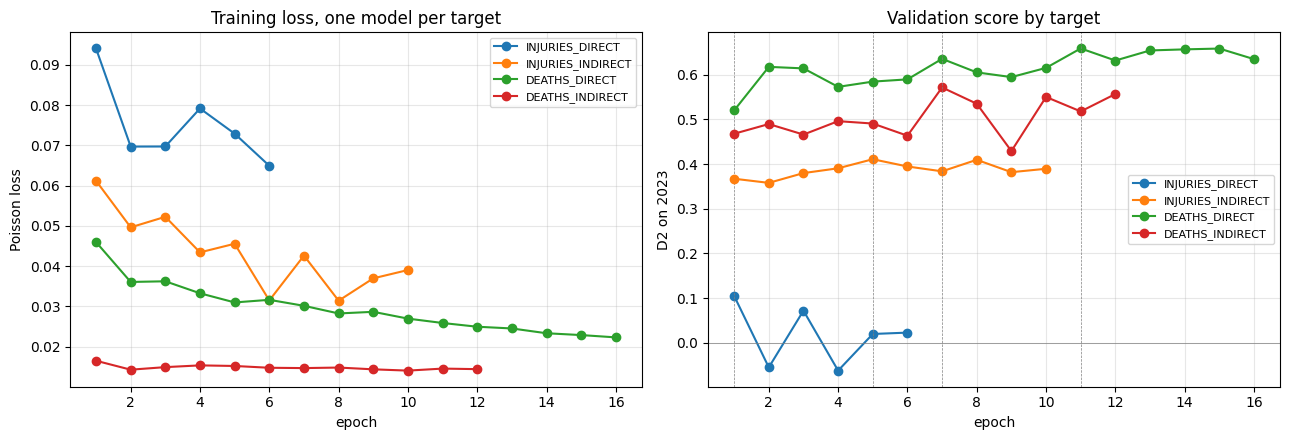

In [22]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for target, result in results.items():
    history = result["history"]
    axes[0].plot(history["epoch"], history["loss"], marker="o", label=target)
    axes[1].plot(history["epoch"], history["val_D2"], marker="o", label=target)
    axes[1].axvline(result["best_epoch"], color="grey", linewidth=0.5, linestyle="--")

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Poisson loss")
axes[0].set_title("Training loss, one model per target")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("D2 on 2023")
axes[1].set_title("Validation score by target")
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
figure.tight_layout()
plt.show()

In [23]:
###########################################
# Adaptive Conformal Prediction
###########################################


def finite_sample_conformal_quantile(scores, alpha):
    """Computes the finite-sample-corrected (1-alpha)
    quantile of the calibration scores."""
    scores = np.sort(np.asarray(scores, dtype=float))
    rank = int(np.ceil((len(scores) + 1) * (1.0 - alpha)))

    if rank > len(scores):
        return np.inf

    return float(scores[rank - 1])


def adaptive_conformal_by_period(
    y_true,
    y_pred,
    dates,
    calibration_scores,
    alpha_target=0.10,
    gamma=0.01,
):
    """Adaptive conformal intervals updated once per temporal period."""
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    period_dates = pd.DatetimeIndex(dates).normalize()

    lower = np.empty(len(actual))
    upper = np.empty(len(actual))
    covered = np.empty(len(actual), dtype=bool)
    alphas = np.empty(len(actual))

    alpha_t = alpha_target
    min_alpha = max(
        1e-3,
        1.0 / (len(calibration_scores) + 1),
    )

    for period in np.unique(period_dates):
        positions = np.flatnonzero(period_dates == period)

        alpha_t = float(np.clip(alpha_t, min_alpha, 0.999))
        q = finite_sample_conformal_quantile(calibration_scores, alpha_t)

        margin = q * np.sqrt(np.clip(predicted[positions], 1, None))
        lower[positions] = np.maximum(0.0, predicted[positions] - margin)
        upper[positions] = predicted[positions] + margin
        covered[positions] = (
            (actual[positions] >= lower[positions])
            & (actual[positions] <= upper[positions])
        )
        alphas[positions] = alpha_t

        alpha_t += gamma * (
            alpha_target - (1.0 - covered[positions].mean())
        )

    return lower, upper, upper - lower, covered, alphas


def _aggregate_split_predictions(
    predictions,
    split,
    freq,
    group_column=None,
    group_name=None,
):
    """Filters predictions to the given split and resamples
    the actual/predicted values by summing them at the given time."""
    split_mask = predictions["split"].eq(split)
    split_data = predictions.loc[
        split_mask,
        ["actual", "predicted"],
    ].copy()

    if group_name is not None:
        group_values = predictions.loc[split_mask, group_column]
        group_mask = group_values.eq(group_name).to_numpy()
        split_data.loc[~group_mask, ["actual", "predicted"]] = 0.0

    return split_data.resample(freq).sum()


def build_daily_base(predictions, group_column=None, group_name=None):
    """THE base measure: daily totals of actual and predicted, one row per
    calendar day, for the calibration and test splits."""
    return {
        split: _aggregate_split_predictions(
            predictions,
            split=split,
            freq="D",
            group_column=group_column,
            group_name=group_name,
        )
        for split in ("calibration", "test")
    }


CALIBRATION_WINDOW_DAYS = {"D": 1, "MS": 30}


def conformity_scores(daily_calibration, window_days):
    """Poisson-standardized absolute residuals of the daily base, summed over
    a rolling window as wide as the view will be read at.

    The window is what makes the monthly view usable."""
    frame = daily_calibration
    if window_days > 1:
        frame = frame.rolling(window_days).sum().dropna()

    return np.abs(
        frame["actual"].to_numpy() - frame["predicted"].to_numpy()
    ) / np.sqrt(np.clip(frame["predicted"].to_numpy(), 1, None))


def conformalize_base(
    daily_base,
    freq="D",
    alpha_target=0.10,
    gamma=0.01,
    calibration_window=None,
):
    """Adaptive conformal intervals on the daily base, re-aggregated to a
    monthly view."""
    calibration = daily_base["calibration"]
    test = daily_base["test"]

    if calibration_window is None:
        calibration_window = CALIBRATION_WINDOW_DAYS.get(freq, 1)

    calibration_scores = conformity_scores(calibration, calibration_window)

    if freq != "D":
        test = test.resample(freq).sum()

    lower, upper, width, covered, alphas = adaptive_conformal_by_period(
        y_true=test["actual"].to_numpy(),
        y_pred=test["predicted"].to_numpy(),
        dates=test.index,
        calibration_scores=calibration_scores,
        alpha_target=alpha_target,
        gamma=gamma,
    )

    return test.assign(
        lower=lower,
        upper=upper,
        width=width,
        covered=covered,
        alpha_t=alphas,
    )


def build_group_monthly_conformal(
    predictions,
    group_column=GROUP_COL,
    alpha_target=0.10,
    gamma=0.01,
    calibration_window=None,
):
    """One monthly conformal frame per event group, keyed by group name."""
    if group_column not in predictions.columns:
        return {}

    test_records = (
        predictions[predictions["split"].eq("test")]
        .groupby(group_column, observed=True)
        .size()
    )

    group_conformal = {}
    for group_name in predictions[group_column].dropna().unique():
        monthly = conformalize_base(
            build_daily_base(
                predictions,
                group_column=group_column,
                group_name=group_name,
            ),
            freq="MS",
            alpha_target=alpha_target,
            gamma=gamma,
            calibration_window=calibration_window,
        )
        monthly.attrs["test_records"] = int(test_records.get(group_name, 0))
        group_conformal[group_name] = monthly

    return group_conformal


### Predictions

In [24]:
###################################
# One prediction per target
###################################

SPLIT_ORDER = ["train", "validation", "calibration", "test"]
MODEL_LABEL = "spatio-temporal transformer"
POINT_METRIC_COLUMNS = ["n", "events", "D2", "RMSE", "MPD"]


def build_target_predictions(result, splits_raw, group_column=GROUP_COL):
    """One long frame per target: actual, predicted, split label and event group."""
    blocks = []
    for name in SPLIT_ORDER:
        frame = splits_raw[name]
        view = result["views"][name]
        block = pd.DataFrame(
            {"split": name,
             "actual": view["y"][:, 0].cpu().numpy(),
             "predicted": predict(result["params"], view)[:, 0]},
            index=frame.index)
        if group_column is not None and group_column in frame.columns:
            block[group_column] = frame[group_column].to_numpy()
        blocks.append(block)

    return pd.concat(blocks).sort_index(kind="stable")


def point_metrics(predictions):
    """n, events, D2, RMSE and MPD for one target, split by split."""
    rows = []
    for name in SPLIT_ORDER:
        part = predictions[predictions["split"].eq(name)]
        if len(part):
            rows.append({"split": name, **compute_metrics(part["actual"], part["predicted"])})

    return pd.DataFrame(rows).set_index("split")


def group_point_metrics(predictions, group_column=GROUP_COL):
    empty = pd.DataFrame(
        columns=POINT_METRIC_COLUMNS,
        index=pd.MultiIndex.from_arrays([[], []], names=["split", group_column]))

    if group_column not in predictions.columns:
        return empty

    rows = []
    for name in SPLIT_ORDER:
        part = predictions[predictions["split"].eq(name)]
        for group_name, block in part.groupby(group_column, observed=True):
            rows.append({"split": name, group_column: group_name,
                         **compute_metrics(block["actual"], block["predicted"])})

    return pd.DataFrame(rows).set_index(["split", group_column]) if rows else empty


def assemble_target_result(result, splits_raw, group_column=GROUP_COL,
                           alpha_target=0.10, gamma=0.01):
    predictions = build_target_predictions(result, splits_raw, group_column)
    daily_base = build_daily_base(predictions)

    return {
        **result,
        "model_name": MODEL_LABEL,
        "predictions": predictions,
        "metrics": point_metrics(predictions),
        "group_metrics": group_point_metrics(predictions, group_column),
        "daily_conformal": conformalize_base(daily_base, freq="D",
                                             alpha_target=alpha_target, gamma=gamma),
        "monthly_conformal": conformalize_base(daily_base, freq="MS",
                                               alpha_target=alpha_target, gamma=gamma),
        "group_monthly_conformal": build_group_monthly_conformal(
            predictions, group_column=group_column,
            alpha_target=alpha_target, gamma=gamma),
    }


def build_forecast_results(results, splits_raw, group_column=GROUP_COL,
                           alpha_target=0.10, gamma=0.01):
    forecast = {}

    for target, result in results.items():
        print(f"[{MODEL_LABEL}] scoring {target}...")
        forecast[target] = assemble_target_result(result, splits_raw, group_column,
                                                  alpha_target, gamma)

    return forecast

started = time.time()
forecast_results = build_forecast_results(results, splits_raw)
print(f"\nscoring wall time: {time.time() - started:.1f} s")


[spatio-temporal transformer] scoring INJURIES_DIRECT...
[spatio-temporal transformer] scoring INJURIES_INDIRECT...
[spatio-temporal transformer] scoring DEATHS_DIRECT...
[spatio-temporal transformer] scoring DEATHS_INDIRECT...

scoring wall time: 19.0 s


### Reporting

In [25]:
#############################################################
# Reporting tables
#############################################################

def _order_splits(frame, column="Split"):
    """Train, validation, calibration, then test: the splits in the order they occur in time."""
    frame[column] = pd.Categorical(frame[column], categories=SPLIT_ORDER, ordered=True)
    return frame


def _select_targets(results, targets):
    """filter results per targets"""
    if targets is None:
        return results
    if isinstance(targets, str):
        targets = [targets]

    missing = [name for name in targets if name not in results]
    if missing:
        raise KeyError(f"{missing} not in results: available are {list(results)}")

    return {name: results[name] for name in targets}


def point_metrics_by_target(results, targets=None):
    """point metrics tables per outcome"""
    selected = _select_targets(results, targets)
    df = pd.concat({k: v["metrics"] for k, v in selected.items()})
    df.index.names = ["Target", "Split"]

    return _order_splits(df.reset_index()).set_index(["Target", "Split"]).sort_index()


def point_metrics_by_event_group(results, group_column=GROUP_COL, targets=None):
    """point metrics tables per outcome and event group"""
    frames = {
        k: v["group_metrics"]
        for k, v in _select_targets(results, targets).items()
        if v.get("group_metrics") is not None and not v["group_metrics"].empty
    }

    if not frames:
        index = pd.MultiIndex.from_arrays([[], [], []], names=["Target", "Split", group_column])
        return pd.DataFrame(columns=POINT_METRIC_COLUMNS, index=index)

    df = pd.concat(frames)
    df.index.names = ["Target", "Split", group_column]

    return _order_splits(df.reset_index()).set_index(["Target", "Split", group_column]).sort_index()


def event_monthly_conformal_summary(results, group_column=GROUP_COL):
    """Coverage per target and event group, read on the monthly view of the
    daily base."""
    rows = [
        {
            "Target": target,
            group_column: group_name,
            "Months": len(frame),
            "TestRecords": frame.attrs.get("test_records", 0),
            "Coverage": float(frame["covered"].mean()),
            "MeanActual": float(frame["actual"].mean()),
            "MeanWidth": float(frame["width"].mean()),
        }
        for target, result in results.items()
        for group_name, frame in result["group_monthly_conformal"].items()
    ]

    summary = pd.DataFrame(rows).set_index(["Target", group_column]).sort_index()

    return _add_relative_width(summary)


def _add_relative_width(summary):
    """Reads the band width against the level it is measuring.

    MeanWidth is in target units - deaths per month, injuries per day - so it
    cannot be compared across targets, views or event groups. RelWidth can:
    it is MeanWidth over MeanActual."""
    mean_actual = summary["MeanActual"]
    summary["RelWidth"] = summary["MeanWidth"] / mean_actual.where(mean_actual > 0)

    return summary


def daily_conformal_summary(results):
    """target coverage: it starts from daily results aggregated by target"""
    df = pd.concat({k: v["daily_conformal"] for k, v in results.items()})
    df.index.names = ["Target", "Date"]

    grouped = df.reset_index().groupby("Target")
    summary = pd.DataFrame({
        "Days": grouped["covered"].size(),
        "Coverage": grouped["covered"].mean(),
        "MeanActual": grouped["actual"].mean(),
        "MeanWidth": grouped["width"].mean(),
    })

    return _add_relative_width(summary)

In [26]:
# ==============================================================================
# MONTHLY TOTAL: ACTUAL VS PREDICTED (FULL TIMELINE)
# ==============================================================================

TEST_YEAR = TEST_START.year

SHADED_SPLITS = {"validation": 0.12, "calibration": 0.20, "test": 0.30}


def plot_monthly_actual_vs_predicted(results, targets, freq="MS"):
    """Monthly totals for 4 targets organized in a 2x2 subplot grid."""
    label = MODEL_LABEL

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), layout="constrained")
    axes = axes.flatten()

    for idx, target in enumerate(targets[:4]):
        ax = axes[idx]
        predictions = results[target]["predictions"]
        monthly = predictions[["actual", "predicted"]].resample(freq).sum()

        for split_name, shade in SHADED_SPLITS.items():
            stamps = predictions.index[predictions["split"] == split_name]
            if len(stamps) == 0:
                continue
            ax.axvspan(
                stamps.min(),
                stamps.max(),
                color="grey",
                alpha=shade,
                linewidth=0,
                zorder=0,
            )

        ax.plot(
            monthly.index,
            monthly["predicted"],
            color="#e07b39",
            linewidth=2.0,
            label="predicted",
        )
        ax.plot(
            monthly.index,
            monthly["actual"],
            color="#1f4e79",
            linewidth=2.0,
            marker="o",
            markersize=3,
            label="actual",
        )

        ax.set_title(
            f"{target}: monthly view, actual vs {label}", fontsize=12
        )
        ax.set_xlabel("Month")
        ax.set_ylabel(f"{target.replace('_', ' ').capitalize()} per month")
        ax.legend(fontsize=10)

    plt.show()

In [27]:
# ==============================================================================
# MONTHLY CONFORMAL PREDICTION INTERVALS
# ==============================================================================


def plot_conformal_monthly(results, targets, test_year=None):
    """Plot monthly adaptive conformal intervals."""
    label = MODEL_LABEL
    test_year = TEST_YEAR if test_year is None else test_year

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10),
        layout="constrained",
    )
    axes = axes.flatten()

    for idx, target in enumerate(targets[:4]):
        ax = axes[idx]

        monthly = results[target]["monthly_conformal"]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(
            x,
            monthly["predicted"],
            color="#e07b39",
            linewidth=2.0,
            label="predicted",
        )
        ax.plot(
            x,
            monthly["actual"],
            color="#1f4e79",
            linewidth=2.0,
            marker="o",
            markersize=4,
            label="actual",
        )

        target_clean = target.replace("_", " ").capitalize()
        ax.set_title(
            f"{target_clean}, {test_year}: monthly adaptive conformal interval ({label})",
            fontsize=12,
        )
        ax.set_xlabel("Month")
        ax.set_ylabel(target_clean)
        ax.legend(fontsize=9, loc="upper left")

    plt.show()


def plot_conformal_monthly_by_event(
    results,
    target,
    test_year=None,
    event_groups=None,
    group_column=GROUP_COL,
    ncols=4,
):
    """Plot group-specific monthly conformal intervals for all event groups."""
    label = MODEL_LABEL
    test_year = TEST_YEAR if test_year is None else test_year
    group_conformal = results[target]["group_monthly_conformal"]

    group_counts = pd.Series(
        {
            name: frame.attrs.get("test_records", 0)
            for name, frame in group_conformal.items()
        },
        dtype=int,
    ).sort_values(ascending=False)

    if event_groups is not None:
        if isinstance(event_groups, str):
            event_groups = [event_groups]
        groups_to_plot = list(event_groups)
    else:
        groups_to_plot = group_counts.index.tolist()

    n_plots = len(groups_to_plot)
    cols = min(ncols, n_plots)
    rows = int(np.ceil(n_plots / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(5.0 * cols, 3.6 * rows),
        layout="constrained",
        squeeze=False,
    )
    axes = axes.flatten()

    target_clean = target.replace("_", " ").capitalize()
    legend_handles = None

    for idx, group_name in enumerate(groups_to_plot):
        ax = axes[idx]
        group_clean = str(group_name).replace("_", " ").capitalize()
        n_events = int(group_counts.get(group_name, 0))

        if n_events == 0:
            ax.set_title(f"{group_clean} - no test data", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        monthly = group_conformal[group_name]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(x, monthly["predicted"], color="#e07b39", linewidth=1.8,
                label="predicted")
        ax.plot(x, monthly["actual"], color="#1f4e79", linewidth=1.8,
                marker="o", markersize=3, label="actual")

        ax.set_title(f"{group_clean} (n test = {n_events})", fontsize=10)
        ax.tick_params(labelsize=8)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

        if idx % cols == 0:
            ax.set_ylabel(f"Monthly {target_clean}", fontsize=9)
        if idx >= n_plots - cols:
            ax.set_xlabel("Month", fontsize=9)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f"{target_clean} - monthly conformal intervals by event, "
        f"{test_year} - {label}",
        fontsize=14,
    )
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="outside lower center",
            ncols=3,
            fontsize=10,
        )
    plt.show()

In [28]:
display(point_metrics_by_target(forecast_results).round(4))

n  events      D2    RMSE     MPD
Target            Split                                              
DEATHS_DIRECT     train        773121    7315  0.6947  0.7955  0.0556
                  validation    39686     409  0.6586  0.6921  0.0875
                  calibration   37371     394  0.5328  0.2376  0.0816
                  test          38495     271  0.6216  0.4207  0.0572
DEATHS_INDIRECT   train        773121    2177  0.5213  0.0963  0.0238
                  validation    39686     136  0.5713  0.3779  0.0550
                  calibration   37371     168  0.4644  0.2305  0.0580
                  test          38495     154  0.6026  0.1229  0.0300
INJURIES_DIRECT   train        773121    4879  0.4212  2.7671  0.4102
                  validation    39686     139  0.1048  4.7542  0.7701
                  calibration   37371     147  0.0771  0.5540  0.1802
                  test          38495     104  0.2788  1.0055  0.1520
INJURIES_INDIRECT train        773121    2137  0.4343  2.8837  0.1483
                  validation    39686     101  0.4107  0.4863  0.0859
                  calibration   37371      87  0.3434  0.4342  0.0922
                  test          38495      82  0.5286  0.2915  0.0430

In [29]:
display(point_metrics_by_event_group(forecast_results, targets='INJURIES_DIRECT').round(4))

n  events      D2     RMSE  \
Target          Split       EVENT_GROUP                                         
INJURIES_DIRECT train       Avalanche           2761     191  0.1006   3.2455   
                            Coastal_Flood      22099     541  0.3904   0.6509   
                            Cold               45728      75  0.5651   0.2446   
                            Drought            68812       2 -0.2270   1.3343   
                            Dust               17319     167  0.1910   1.2300   
                            Extreme_Heat       37596     775  0.3527   7.6225   
                            Flooding          159402     683  0.4602   4.0330   
                            High_Wind         145229    1019  0.2092   0.3464   
                            Tropical_Cyclone   11059     160  0.0695   7.6612   
                            Wildfire            8444     509  0.3394   2.0495   
                            Winter_Storm      254672     757  0.3197   0.9919   
                validation  Avalanche            219      13 -0.2475   0.3852   
                            Coastal_Flood        706      31 -0.1133   0.5398   
                            Cold                1095       2  0.3121   0.2837   
                            Drought             5815       0     NaN   0.0007   
                            Dust                 530       1  0.1061   1.6053   
                            Extreme_Heat        8347      27 -0.0582  10.3484   
                            Flooding            6474      11  0.0739   0.0636   
                            High_Wind           7288      32  0.2488   0.1289   
                            Tropical_Cyclone     338       2  0.2207   0.3818   
                            Wildfire             343       6 -0.0116   1.7353   
                            Winter_Storm        8531      14  0.0754   0.1530   
                calibration Avalanche            197      13 -0.2802   0.3414   
                            Coastal_Flood        791      31  0.1984   0.3384   
                            Cold                1844       2 -0.4819   0.3977   
                            Drought             3473       0     NaN   0.0003   
                            Dust                 934       4  0.4366   0.1120   
                            Extreme_Heat        5831      22 -0.0553   0.8224   
                            Flooding            7134      11 -0.0356   0.0728   
                            High_Wind           7564      31  0.2336   0.0976   
                            Tropical_Cyclone     813       8 -0.3798   2.7061   
                            Wildfire             336      12  0.1285   1.3735   
                            Winter_Storm        8454      13  0.1515   0.2205   
                test        Avalanche            197       6  0.5321   0.1539   
                            Coastal_Flood        612      30 -0.0407   0.5791   
                            Cold                3083       1  0.1156   0.0207   
                            Drought             3283       0     NaN   0.0011   
                            Dust                 955       1 -0.1239   0.0474   
                            Extreme_Heat        4303      12  0.0999   2.9874   
                            Flooding            7655      15  0.2652   0.0626   
                            High_Wind           7934      17  0.0594   0.0620   
                            Tropical_Cyclone      35       0     NaN   0.0236   
                            Wildfire             350      12  0.2529   0.7906   
                            Winter_Storm       10088      10  0.0888   0.0505   

                                                 MPD  
Target          Split       EVENT_GROUP               
INJURIES_DIRECT train       Avalanche         1.2882  
                            Coastal_Flood     0.2901  
                            Cold              0.0434  
                            Drought           0.1

In [30]:
display(point_metrics_by_event_group(forecast_results, targets='INJURIES_INDIRECT').round(4))

n  events      D2  \
Target            Split       EVENT_GROUP                                
INJURIES_INDIRECT train       Avalanche           2761       8  0.0973   
                              Coastal_Flood      22099      11  0.0110   
                              Cold               45728      33  0.5939   
                              Drought            68812       2  0.0781   
                              Dust               17319     184  0.5462   
                              Extreme_Heat       37596      40  0.0903   
                              Flooding          159402      70  0.0760   
                              High_Wind         145229     123  0.3201   
                              Tropical_Cyclone   11059      17  0.1896   
                              Wildfire            8444     107  0.3975   
                              Winter_Storm      254672    1542  0.4351   
                  validation  Avalanche            219       1  0.7376   
                              Coastal_Flood        706       2  0.1082   
                              Cold                1095       3  0.4344   
                              Drought             5815       0     NaN   
                              Dust                 530      10  0.4959   
                              Extreme_Heat        8347       0     NaN   
                              Flooding            6474       2  0.1659   
                              High_Wind           7288       2  0.0329   
                              Tropical_Cyclone     338       3  0.0056   
                              Wildfire             343       4 -0.4495   
                              Winter_Storm        8531      74  0.3012   
                  calibration Avalanche            197       1 -0.2564   
                              Coastal_Flood        791       3 -0.2266   
                              Cold                1844       2  0.0972   
                              Drought             3473       0     NaN   
                              Dust                 934      20  0.2780   
                              Extreme_Heat        5831       5  0.0543   
                              Flooding            7134       1 -0.0856   
                              High_Wind           7564       9  0.2951   
                              Tropical_Cyclone     813       5 -0.0359   
                              Wildfire             336       1 -0.2786   
                              Winter_Storm        8454      40  0.3049   
                  test        Avalanche            197       2 -0.2505   
                              Coastal_Flood        612       1  0.1643   
                              Cold                3083       2  0.5540   
                              Drought             3283       0     NaN   
                              Dust                 955      14  0.5424   
                              Extreme_Heat        4303       0     NaN   
                              Flooding            7655       3  0.0235   
                              High_Wind           7934       0     NaN   
                              Tropical_Cyclone      35       0     NaN   
                              Wildfire             350       2 -0.1266   
                              Winter_Storm       10088      58  0.4298   

                                                   RMSE     MPD  
Target            Split       EVENT_GROUP                        
INJURIES_INDIRECT train       Avalanche          0.0717  0.0386  
                              Coastal_Flood      0.0291  0.0089  
                              Cold               0.1264  0.0151  
                              Drought            0.0121  0.0011  
                              Dust               1.0721  0.3101  
                              Extreme_Heat       0.5238  0.1182  
                              Flooding           0.0492  0.0108  
                              High_Wind          0.728

In [31]:
display(point_metrics_by_event_group(forecast_results, targets='DEATHS_DIRECT').round(4))

n  events      D2    RMSE  \
Target        Split       EVENT_GROUP                                        
DEATHS_DIRECT train       Avalanche           2761     354  0.5729  0.9964   
                          Coastal_Flood      22099    1324  0.8283  0.2307   
                          Cold               45728     636  0.7888  0.1946   
                          Drought            68812       0     NaN  0.0007   
                          Dust               17319      64  0.4698  0.1303   
                          Extreme_Heat       37596    1896  0.7522  0.9483   
                          Flooding          159402    1566  0.4678  0.2113   
                          High_Wind         145229     584  0.5680  0.0867   
                          Tropical_Cyclone   11059     202  0.5802  6.2428   
                          Wildfire            8444     115  0.4845  0.9843   
                          Winter_Storm      254672     574  0.5292  0.0922   
              validation  Avalanche            219      15  0.1694  0.5115   
                          Coastal_Flood        706      83  0.8754  0.1925   
                          Cold                1095       9  0.7120  0.1035   
                          Drought             5815       0     NaN  0.0006   
                          Dust                 530       2  0.1709  0.3743   
                          Extreme_Heat        8347     196  0.7775  0.9957   
                          Flooding            6474      54  0.4005  0.1373   
                          High_Wind           7288      34  0.3567  0.0772   
                          Tropical_Cyclone     338       3 -0.0065  0.1008   
                          Wildfire             343       3 -0.0372  5.5029   
                          Winter_Storm        8531      10  0.4160  0.0333   
              calibration Avalanche            197      13  0.4522  0.9191   
                          Coastal_Flood        791      67  0.8146  0.1974   
                          Cold                1844      35  0.4768  0.1941   
                          Drought             3473       0     NaN  0.0036   
                          Dust                 934       1  0.5598  0.0465   
                          Extreme_Heat        5831     132  0.7498  0.3703   
                          Flooding            7134      70  0.1003  0.3165   
                          High_Wind           7564      22  0.4407  0.0751   
                          Tropical_Cyclone     813      31  0.0456  0.4410   
                          Wildfire             336       7  0.1581  0.2085   
                          Winter_Storm        8454      16  0.4406  0.1151   
              test        Avalanche            197      11  0.3038  0.3137   
                          Coastal_Flood        612      56  0.7383  0.1952   
                          Cold                3083      23  0.7533  0.0691   
                          Drought             3283       0     NaN  0.0002   
                          Dust                 955       0     NaN  0.0418   
                          Extreme_Heat        4303      75  0.7041  0.2103   
                          Flooding            7655      74  0.5440  0.8626   
                          High_Wind           7934      15  0.5448  0.0482   
                          Tropical_Cyclone      35       0     NaN  0.1465   
                          Wildfire             350       7  0.3044  1.5471   
                          Winter_Storm       10088      10  0.2551  0.0333   

                                               MPD  
Target        Split       EVENT_GROUP               
DEATHS_DIRECT train       Avalanche         0.3992  
                          Coastal_Flood     0.0704  
                          Cold              0.0343  
                          Drought           0.0002  
                          Dust              0.0359  
                          Extreme_Heat      0.2118  
                          Flooding  

In [32]:
display(point_metrics_by_event_group(forecast_results, targets='DEATHS_INDIRECT').round(4))

n  events      D2    RMSE  \
Target          Split       EVENT_GROUP                                        
DEATHS_INDIRECT train       Avalanche           2761       9  0.0374  0.0717   
                            Coastal_Flood      22099      26  0.1227  0.0470   
                            Cold               45728      92  0.4749  0.0720   
                            Drought            68812       0     NaN  0.0006   
                            Dust               17319     144  0.6303  0.1390   
                            Extreme_Heat       37596     396  0.5654  0.2290   
                            Flooding          159402      98  0.1620  0.0334   
                            High_Wind         145229     116  0.4558  0.0513   
                            Tropical_Cyclone   11059     100  0.5118  0.3849   
                            Wildfire            8444      42  0.3099  0.1445   
                            Winter_Storm      254672    1154  0.4621  0.0928   
                validation  Avalanche            219       1  0.1253  0.0714   
                            Coastal_Flood        706       0     NaN  0.0347   
                            Cold                1095       4  0.7192  0.0794   
                            Drought             5815       0     NaN  0.0002   
                            Dust                 530       8  0.6610  0.3018   
                            Extreme_Heat        8347      83  0.5111  0.8149   
                            Flooding            6474       3  0.2345  0.0306   
                            High_Wind           7288       4 -0.3160  0.0254   
                            Tropical_Cyclone     338       3 -0.3673  0.1529   
                            Wildfire             343       1  0.6756  0.1407   
                            Winter_Storm        8531      29  0.4962  0.0696   
                calibration Avalanche            197       0     NaN  0.0427   
                            Coastal_Flood        791       1  0.1509  0.0386   
                            Cold                1844       3  0.1488  0.0570   
                            Drought             3473       0     NaN  0.0001   
                            Dust                 934      12  0.3582  0.1876   
                            Extreme_Heat        5831      82  0.5474  0.5455   
                            Flooding            7134       8  0.1066  0.0385   
                            High_Wind           7564      10  0.2207  0.0677   
                            Tropical_Cyclone     813      18 -0.1287  0.3610   
                            Wildfire             336       1  0.3335  0.0467   
                            Winter_Storm        8454      33 -0.0109  0.0833   
                test        Avalanche            197       0     NaN  0.0197   
                            Coastal_Flood        612       3  0.1619  0.0724   
                            Cold                3083       2  0.0600  0.0404   
                            Drought             3283       0     NaN  0.0001   
                            Dust                 955      11  0.5888  0.3106   
                            Extreme_Heat        4303      88  0.6738  0.2875   
                            Flooding            7655       5  0.3033  0.0255   
                            High_Wind           7934       4  0.3835  0.0225   
                            Tropical_Cyclone      35       0     NaN  0.0024   
                            Wildfire             350       1  0.5473  0.1001   
                            Winter_Storm       10088      40  0.2598  0.1056   

                                                 MPD  
Target          Split       EVENT_GROUP               
DEATHS_INDIRECT train       Avalanche         0.0402  
                            Coastal_Flood     0.0162  
                            Cold              0.0174  
                            Drought           0.0002  
                            Dust        

In [33]:
display(daily_conformal_summary(forecast_results).round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
DEATHS_DIRECT,365,0.9233,1.3808,2.9633,2.1460
DEATHS_INDIRECT,365,0.9068,0.6932,2.0865,3.0102
INJURIES_DIRECT,365,0.9233,1.4849,2.1197,1.4275
INJURIES_INDIRECT,365,0.9041,0.7096,1.7540,2.4719


In [34]:
display(event_monthly_conformal_summary(forecast_results).round(4))

Months  TestRecords  Coverage  MeanActual  \
Target            EVENT_GROUP                                                   
DEATHS_DIRECT     Avalanche             12          197    1.0000      1.0833   
                  Coastal_Flood         12          612    0.8333      4.8333   
                  Cold                  12         3083    0.9167      2.0833   
                  Drought               12         3283    1.0000      0.0000   
                  Dust                  12          955    0.7500      0.0000   
                  Extreme_Heat          12         4303    1.0000      8.2500   
                  Flooding              12         7655    0.9167     18.4167   
                  High_Wind             12         7934    1.0000      1.4167   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.8333      5.0833   
                  Winter_Storm          12        10088    1.0000      0.8333   
DEATHS_INDIRECT   Avalanche             12          197    0.9167      0.0000   
                  Coastal_Flood         12          612    0.8333      0.2500   
                  Cold                  12         3083    0.9167      0.1667   
                  Drought               12         3283    0.7500      0.0000   
                  Dust                  12          955    0.8333      2.0833   
                  Extreme_Heat          12         4303    0.8333     12.8333   
                  Flooding              12         7655    1.0000      0.4167   
                  High_Wind             12         7934    1.0000      0.3333   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.9167      0.1667   
                  Winter_Storm          12        10088    0.7500      4.8333   
INJURIES_DIRECT   Avalanche             12          197    1.0000      0.5000   
                  Coastal_Flood         12          612    0.8333      5.2500   
                  Cold                  12         3083    1.0000      0.0833   
                  Drought               12         3283    0.9167      0.0000   
                  Dust                  12          955    1.0000      0.0833   
                  Extreme_Heat          12         4303    0.7500     31.4167   
                  Flooding              12         7655    0.9167      1.5833   
                  High_Wind             12         7934    0.9167      1.7500   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.9167      3.2500   
                  Winter_Storm          12        10088    1.0000      1.2500   
INJURIES_INDIRECT Avalanche             12          197    0.7500      0.2500   
                  Coastal_Flood         12          612    1.0000      0.0833   
                  Cold                  12         3083    0.7500      0.2500   
                  Drought               12         3283    0.9167      0.0000   
                  Dust                  12          955    0.9167      7.2500   
                  Extreme_Heat          12         4303    1.0000      0.0000   
                  Flooding              12         7655    0.7500      0.7500   
                  High_Wind             12         7934    1.0000      0.0000   
                  Tropical_Cyclone      12           35    1.0000      0.0000   
                  Wildfire              12          350    0.9167      0.3333   
                  Winter_Storm          12        10088    0.6667     12.6667   

                                    MeanWidth  RelWidth  
Target            EVENT_GROUP                            
DEATHS_DIRECT     Avalanche            4.1089    3.7929  
                  Coastal_Flood        5.1129    1.0578  
                  Cold                 3.2882    1.5783  
                  D

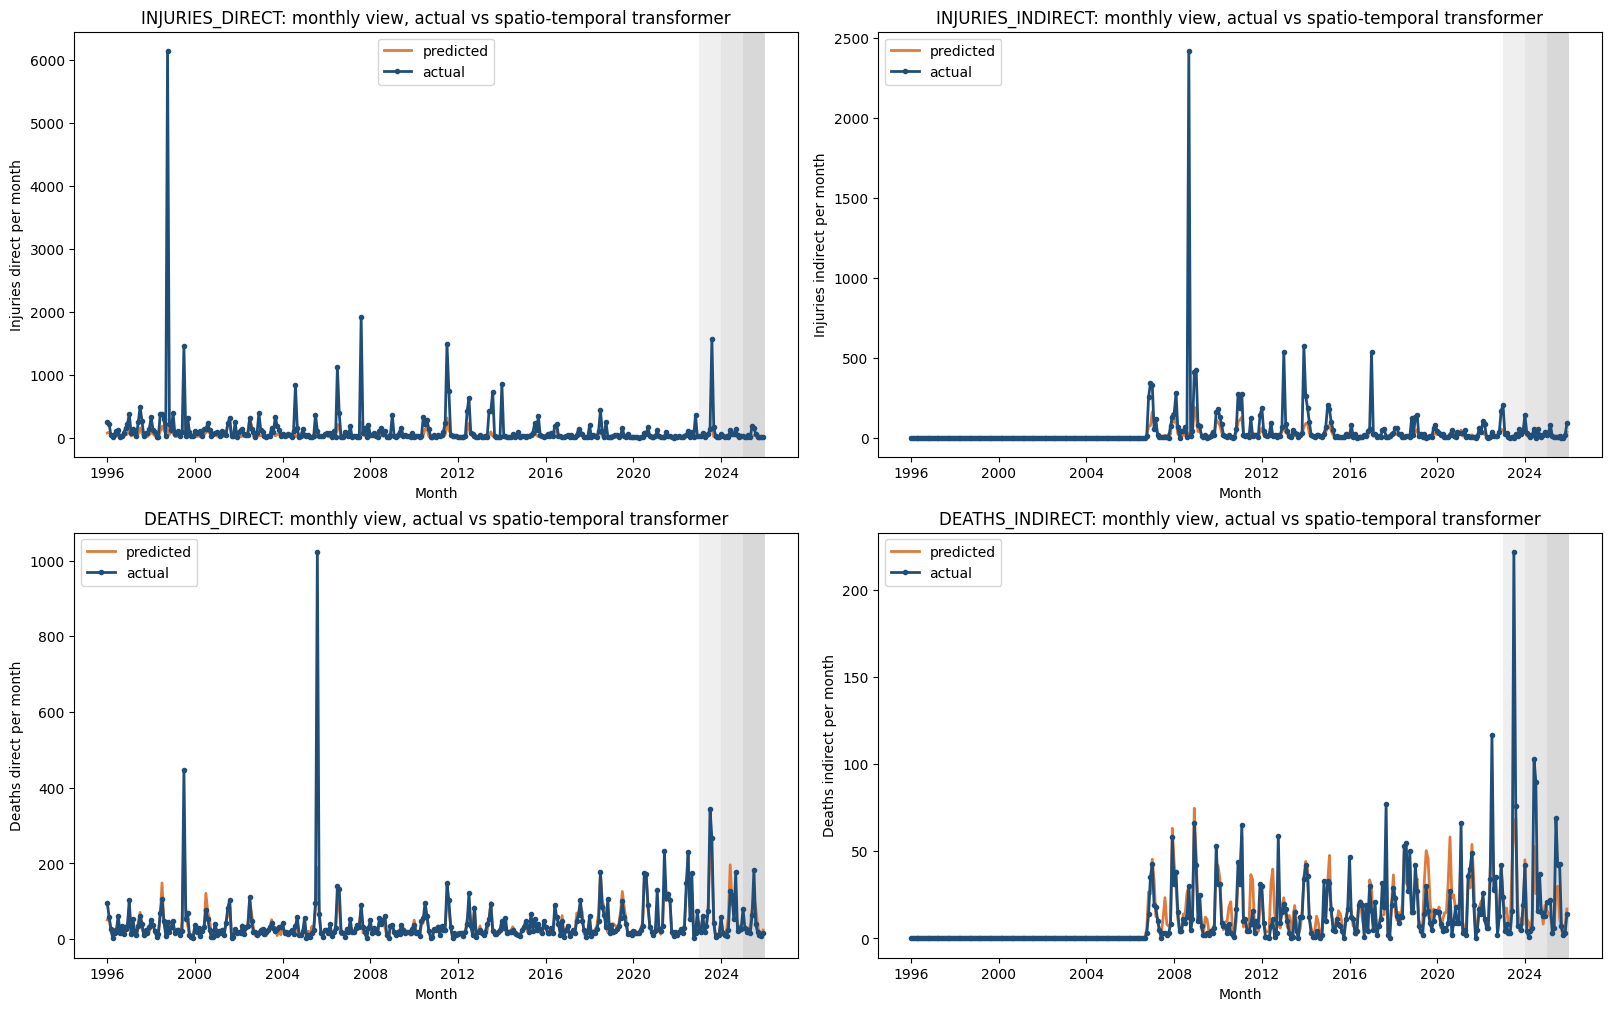

In [35]:
target_list=['INJURIES_DIRECT','INJURIES_INDIRECT','DEATHS_DIRECT','DEATHS_INDIRECT']
plot_monthly_actual_vs_predicted(forecast_results, target_list)

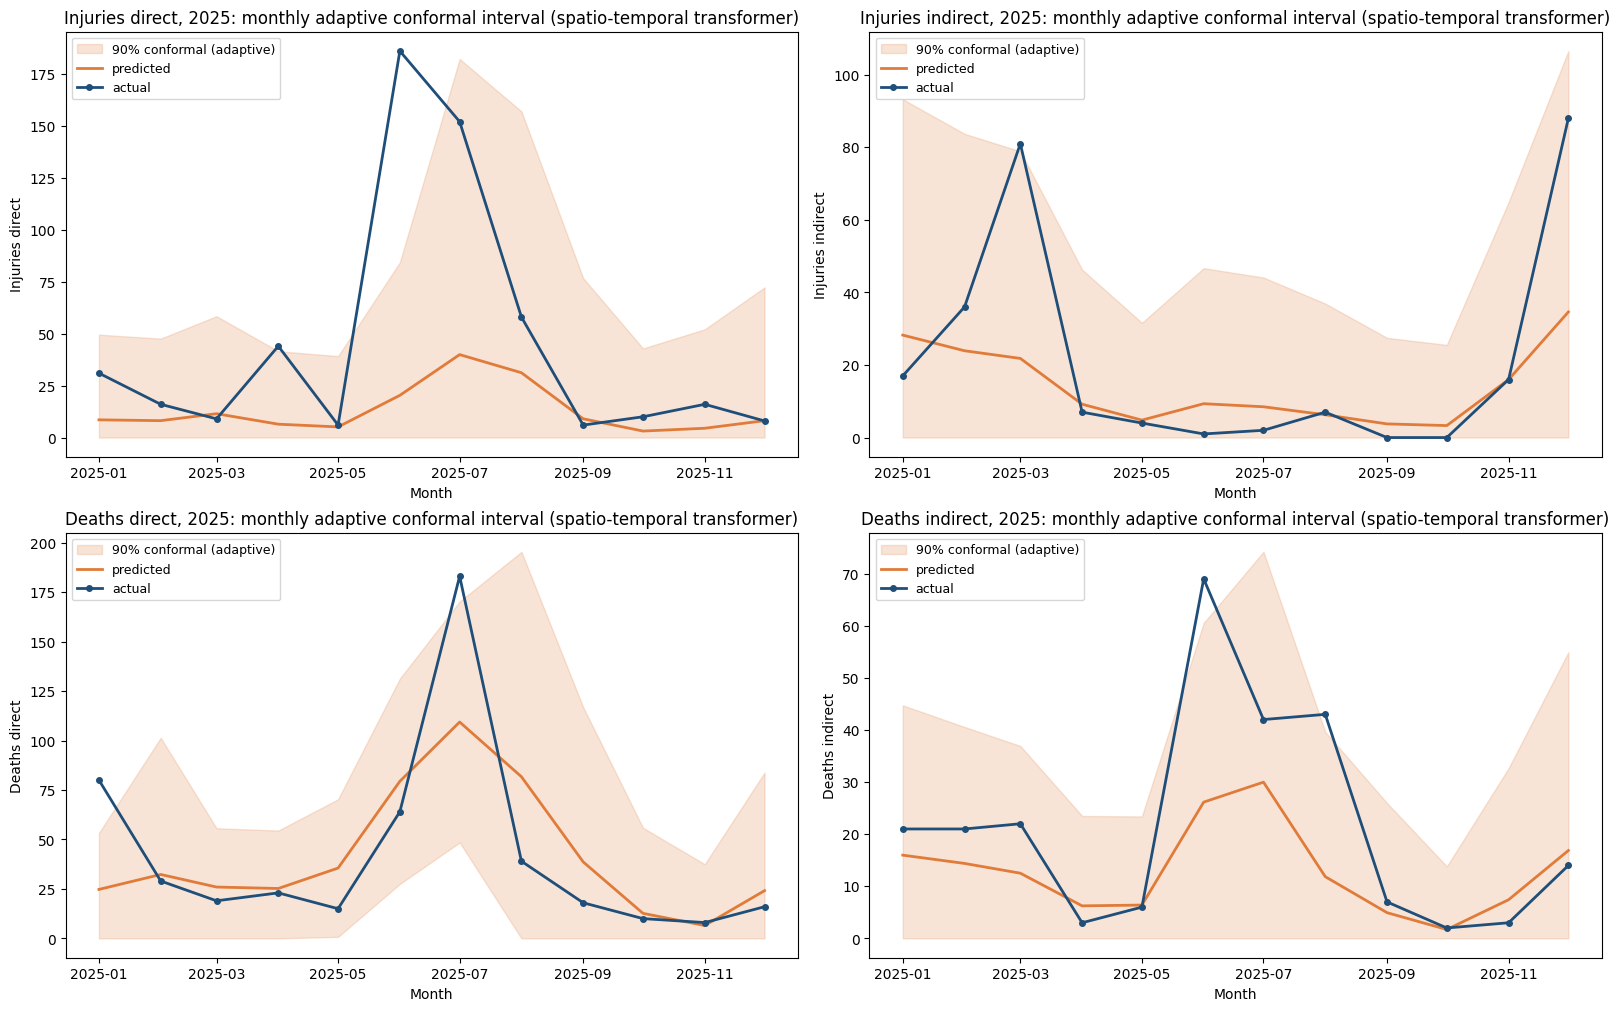

In [36]:
plot_conformal_monthly(forecast_results, target_list, test_year=2025)

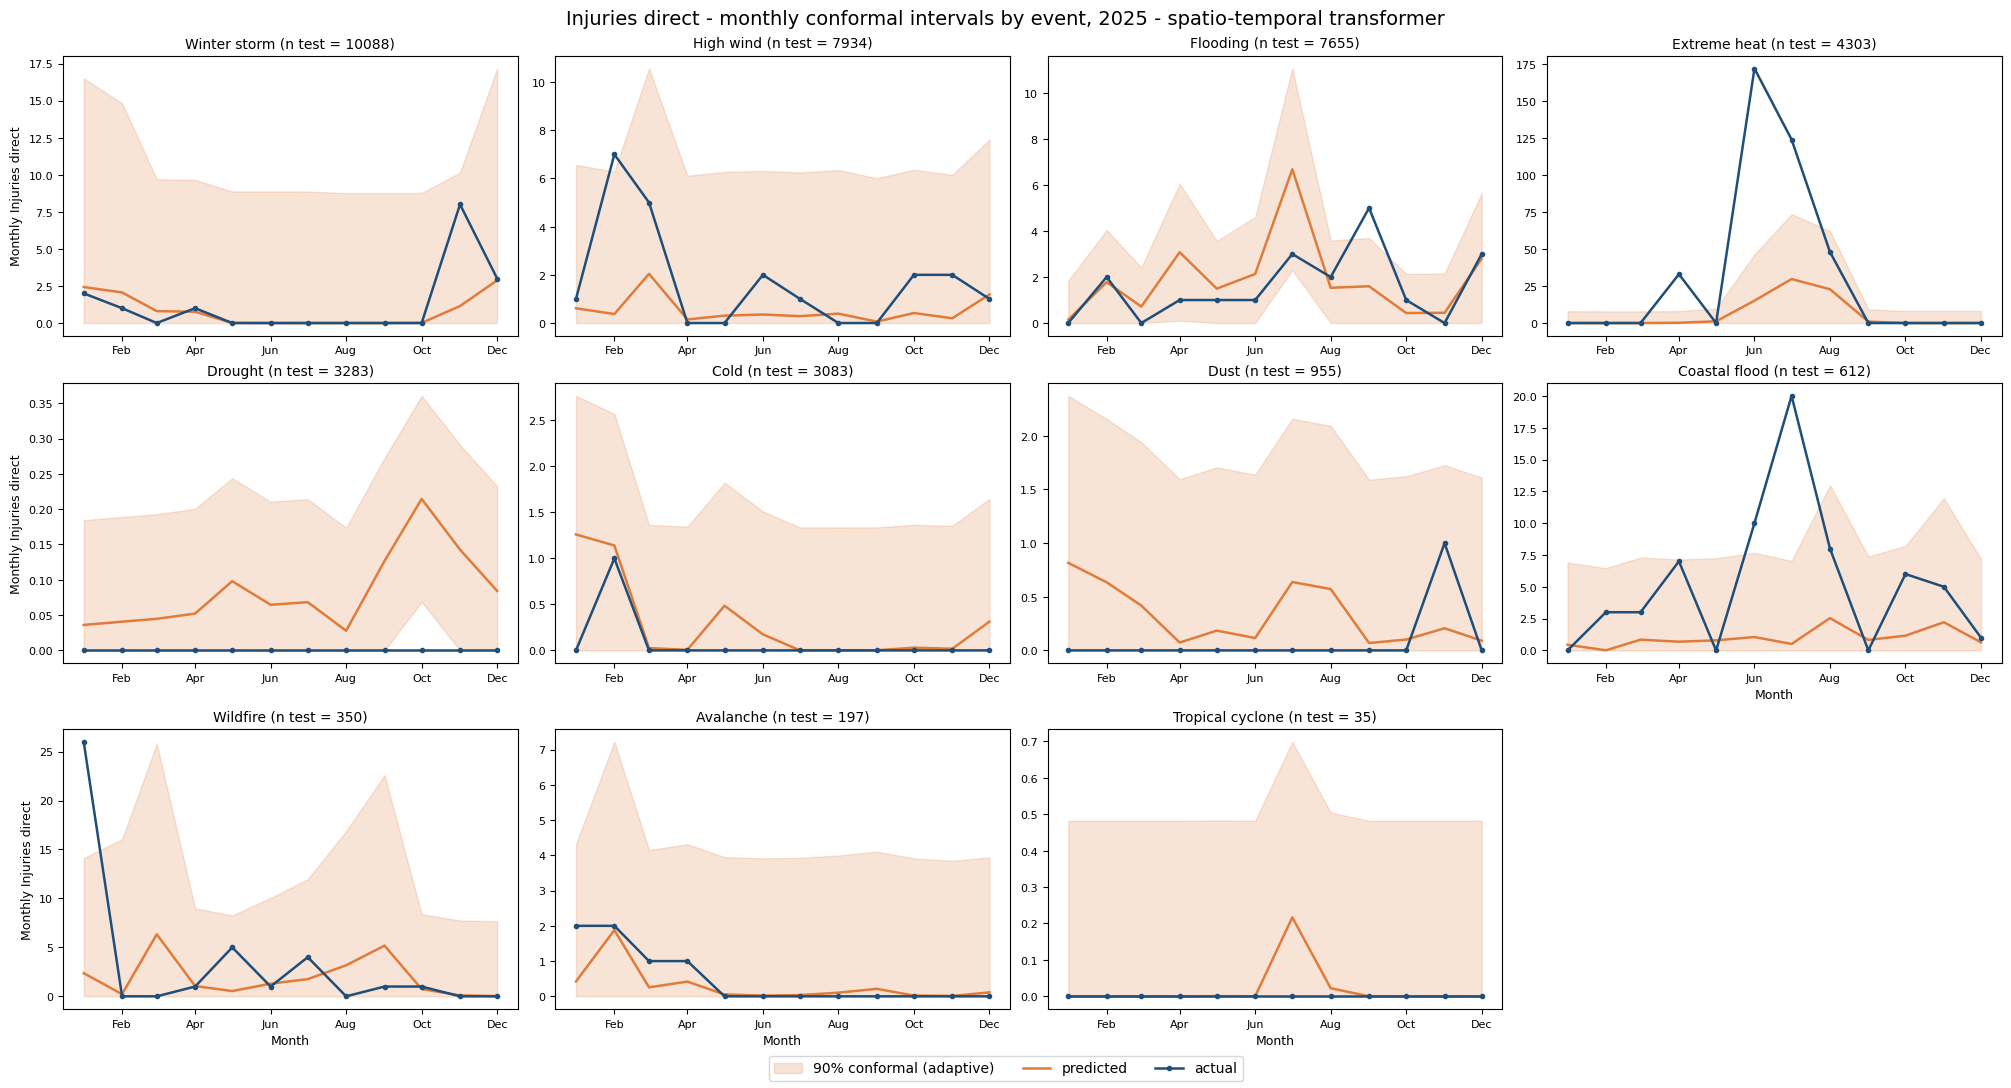

In [37]:
plot_conformal_monthly_by_event(forecast_results, 'INJURIES_DIRECT', test_year=2025)

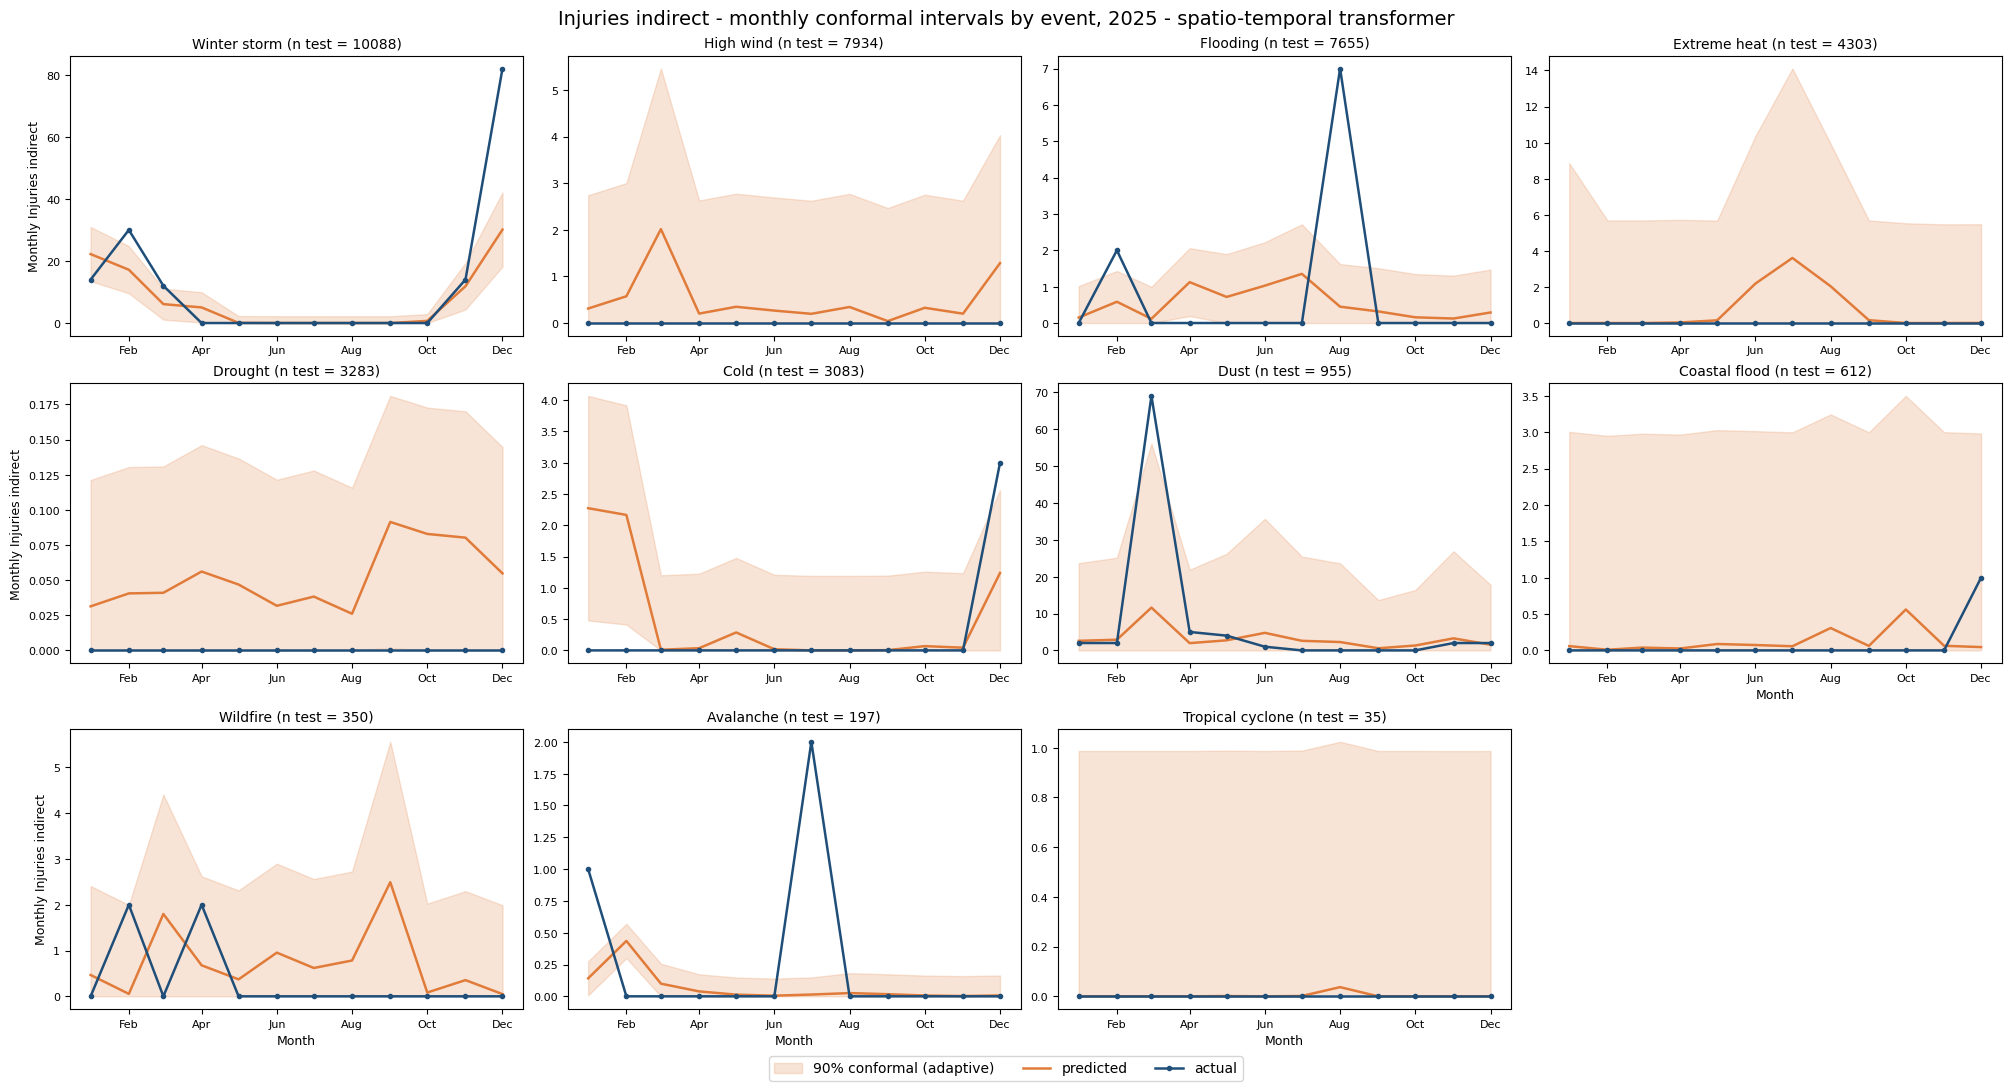

In [38]:
plot_conformal_monthly_by_event(forecast_results, 'INJURIES_INDIRECT', test_year=2025)

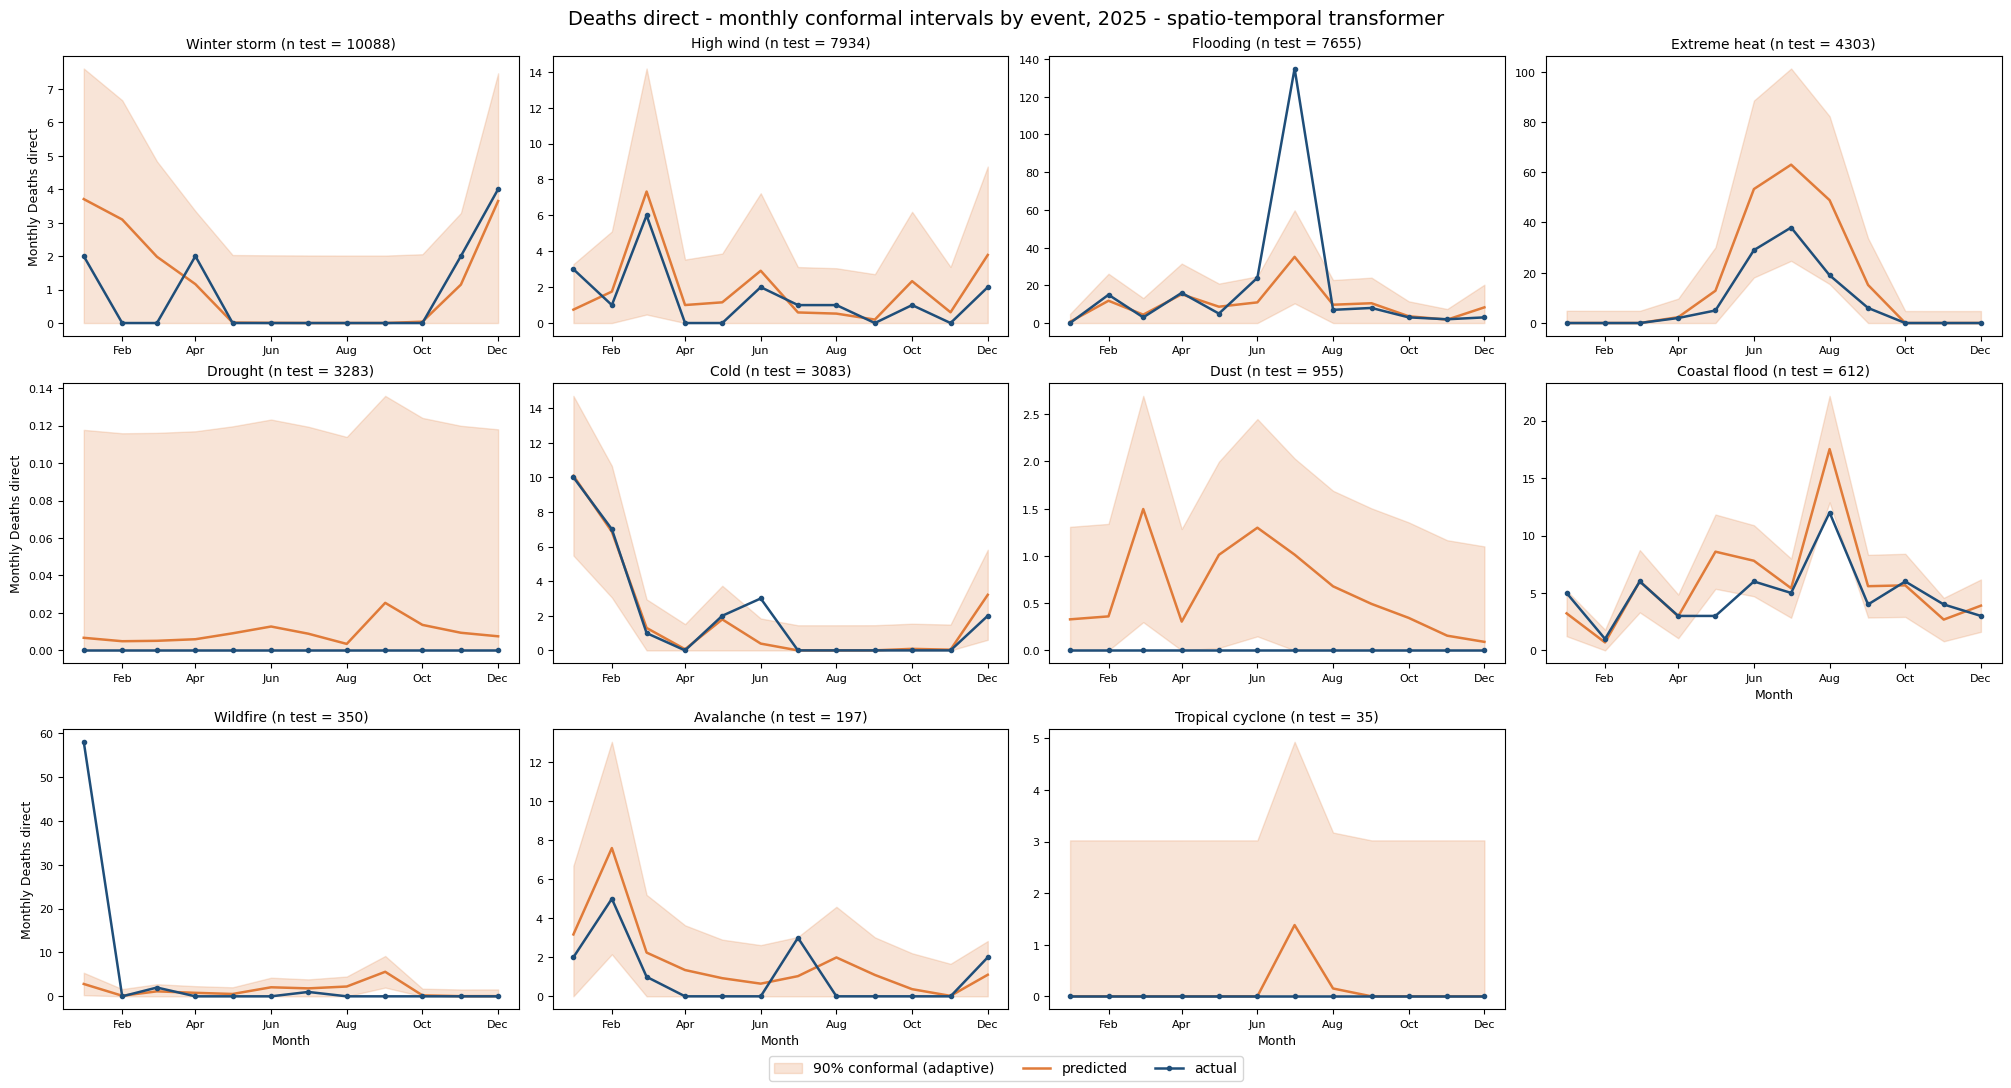

In [39]:
plot_conformal_monthly_by_event(forecast_results, 'DEATHS_DIRECT', test_year=2025)

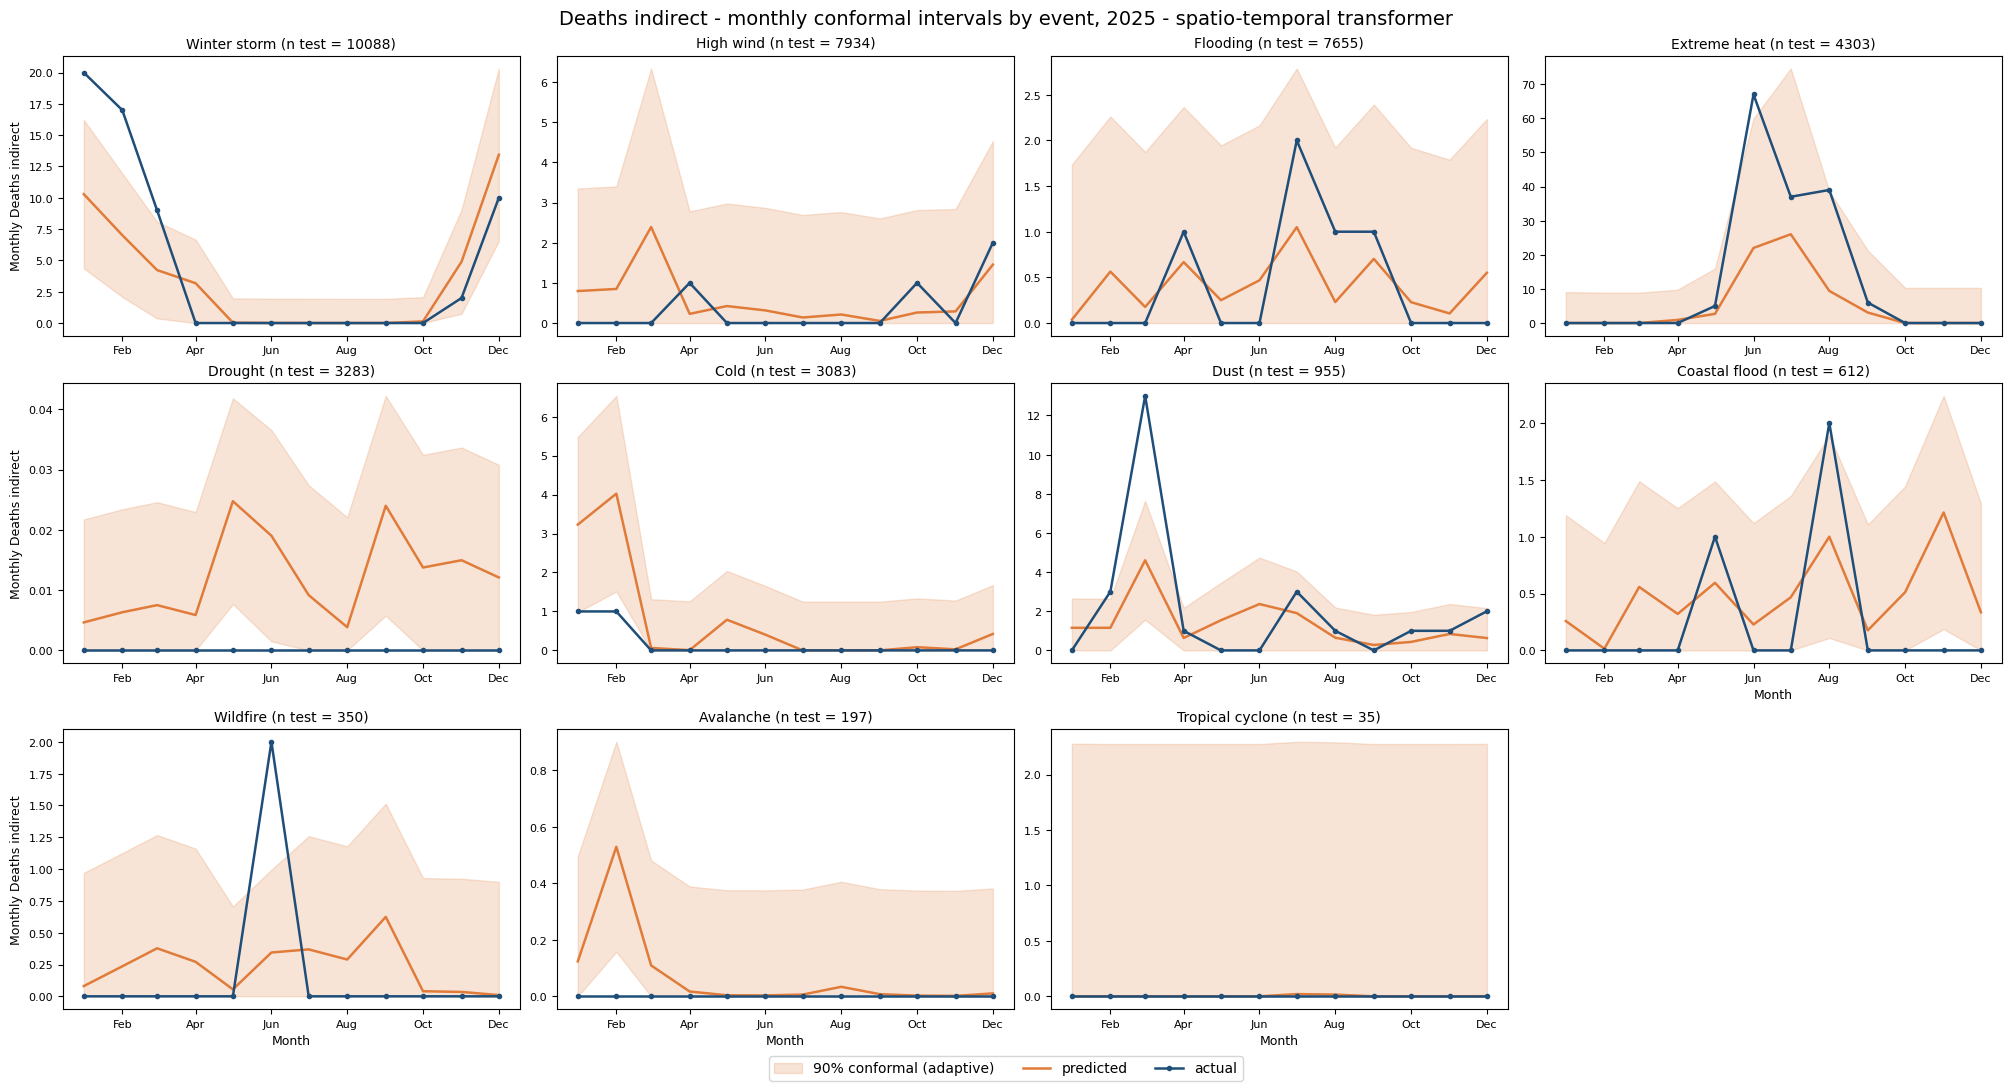

In [40]:
plot_conformal_monthly_by_event(forecast_results, 'DEATHS_INDIRECT', test_year=2025)

### Historical backtesting

In [41]:
###################################################
# Historical backtesting
###################################################



BACKTEST_VALIDATION_YEARS = (2019, 2020, 2021, 2022, 2023)


def expanding_year_splits(frame, validation_years=BACKTEST_VALIDATION_YEARS):
    """Train on every year strictly before val_year, validate on val_year alone."""
    years = frame.index.year.to_numpy()
    for fold, val_year in enumerate(validation_years, start=1):
        yield (fold, val_year,
               np.flatnonzero(years < val_year),
               np.flatnonzero(years == val_year))


def backtest_target_cv(frame, config, target, epochs,
                       validation_years=BACKTEST_VALIDATION_YEARS):
    """backtesting end-to-end pipeline."""
    index = PREDICTION_TARGETS.index(target)
    records = []

    print("=" * 78)
    print(f"backtesting {target} at {epochs} epochs per fold")
    print("=" * 78)

    for fold, val_year, train_index, val_index in expanding_year_splits(frame, validation_years):
        fold_train = frame.iloc[train_index].copy()
        fold_validation = frame.iloc[val_index].copy()
        encoders = fit_encoders(fold_train)
        tensors = {"train": encode_split(fold_train, encoders),
                   "validation": encode_split(fold_validation, encoders)}
        cardinalities = [len(encoders["vocabularies"][column]) + 1 for column in CATEGORICAL]
        views = {name: target_view(part, index) for name, part in tensors.items()}

        print(f"fold {fold}: train <= {val_year - 1} ({len(fold_train):,} rows)   "
              f"validation = {val_year} ({len(fold_validation):,} rows)")

        baseline_rate = (views["train"]["y"].sum(dim=0)
                         / views["train"]["exposure"].sum()).clamp(min=1e-8)
        fold_params = make_params(config, cardinalities, baseline_rate)
        train_model(fold_params, views["train"], config, epochs=epochs)
        predicted = predict(fold_params, views["validation"])[:, 0]

        records.append(pd.DataFrame(
            {"fold": fold, "validation_year": val_year,
             "actual": views["validation"]["y"][:, 0].cpu().numpy(),
             "predicted": predicted},
            index=fold_validation.index))

        del fold_params, tensors, views, fold_train, fold_validation
        gc.collect()
        torch.cuda.empty_cache()

    return pd.concat(records).sort_index(kind="stable")

In [42]:
started = time.time()
oof = {target: backtest_target_cv(train_events, MODEL_CONFIG, target, results[target]["best_epoch"])
       for target in PREDICTION_TARGETS}
torch.cuda.synchronize()
print(f"\nbacktest wall time: {(time.time() - started) / 60:.1f} min")


backtesting INJURIES_DIRECT at 1 epochs per fold
fold 1: train <= 2018 (627,316 rows)   validation = 2019 (36,353 rows)
  epoch   1  loss   0.08174
fold 2: train <= 2019 (663,669 rows)   validation = 2020 (31,055 rows)
  epoch   1  loss   0.10036
fold 3: train <= 2020 (694,724 rows)   validation = 2021 (36,224 rows)
  epoch   1  loss   0.09633
fold 4: train <= 2021 (730,948 rows)   validation = 2022 (42,173 rows)
  epoch   1  loss   0.09558
fold 5: train <= 2022 (773,121 rows)   validation = 2023 (39,686 rows)
  epoch   1  loss   0.09410
backtesting INJURIES_INDIRECT at 5 epochs per fold
fold 1: train <= 2018 (627,316 rows)   validation = 2019 (36,353 rows)
  epoch   1  loss   0.06676
  epoch   2  loss   0.04857
  epoch   3  loss   0.04810
  epoch   4  loss   0.03522
  epoch   5  loss   0.05291
fold 2: train <= 2019 (663,669 rows)   validation = 2020 (31,055 rows)
  epoch   1  loss   0.06661
  epoch   2  loss   0.04453
  epoch   3  loss   0.03549
  epoch   4  loss   0.03935
  epoch   5

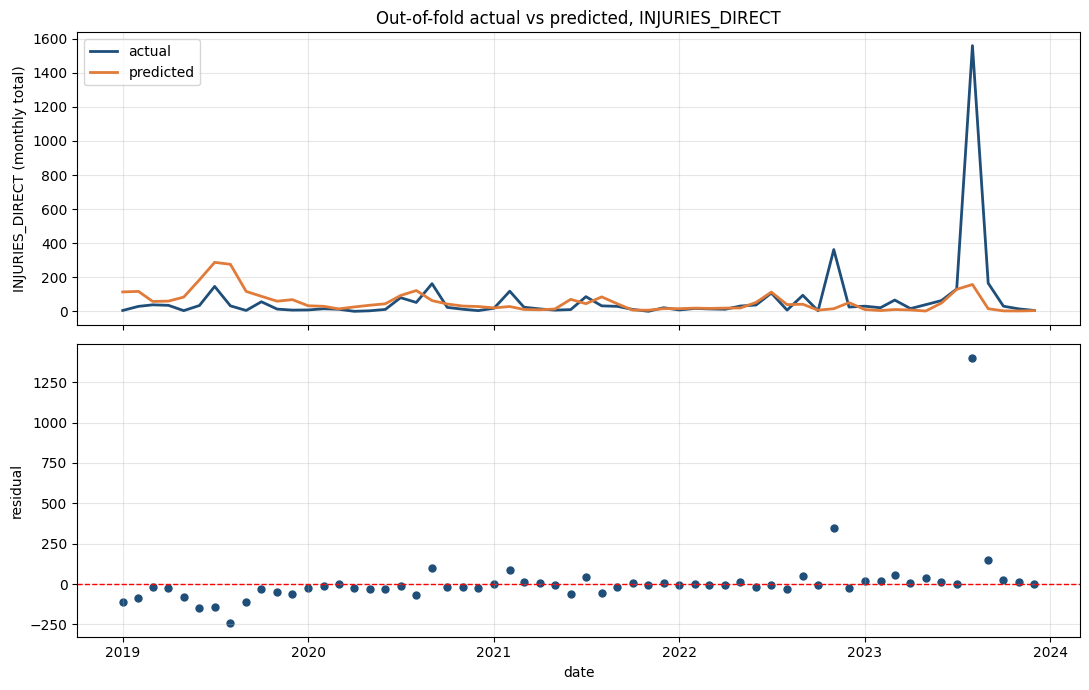

,n,events,D2,RMSE,MPD,ratio
year,,,,,,
2019,36353,96,0.0879,0.4775,0.1400,3.6609
2020,31055,103,0.3849,0.6278,0.1070,1.4525
2021,36224,101,0.2163,0.6106,0.1161,0.9591
2022,42173,120,0.0107,1.7495,0.2713,0.5765
2023,39686,139,0.1048,4.7542,0.7701,0.1883


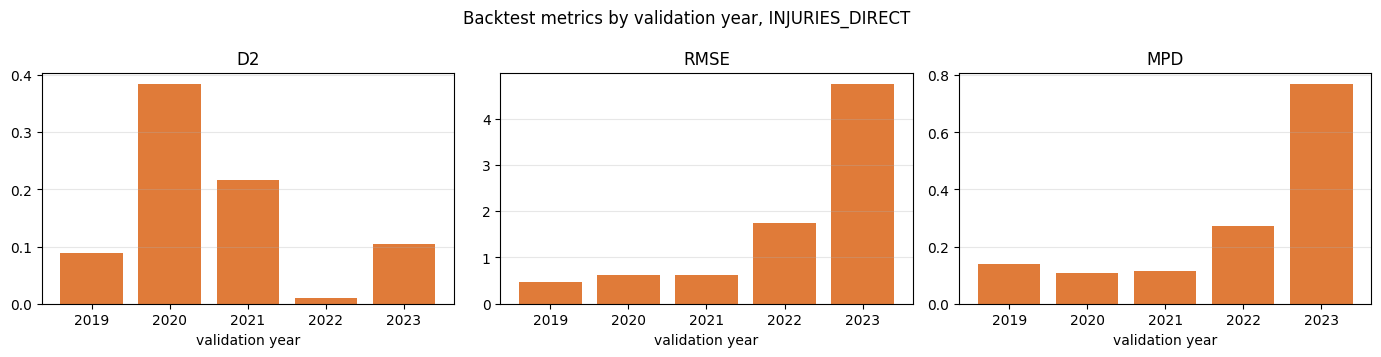

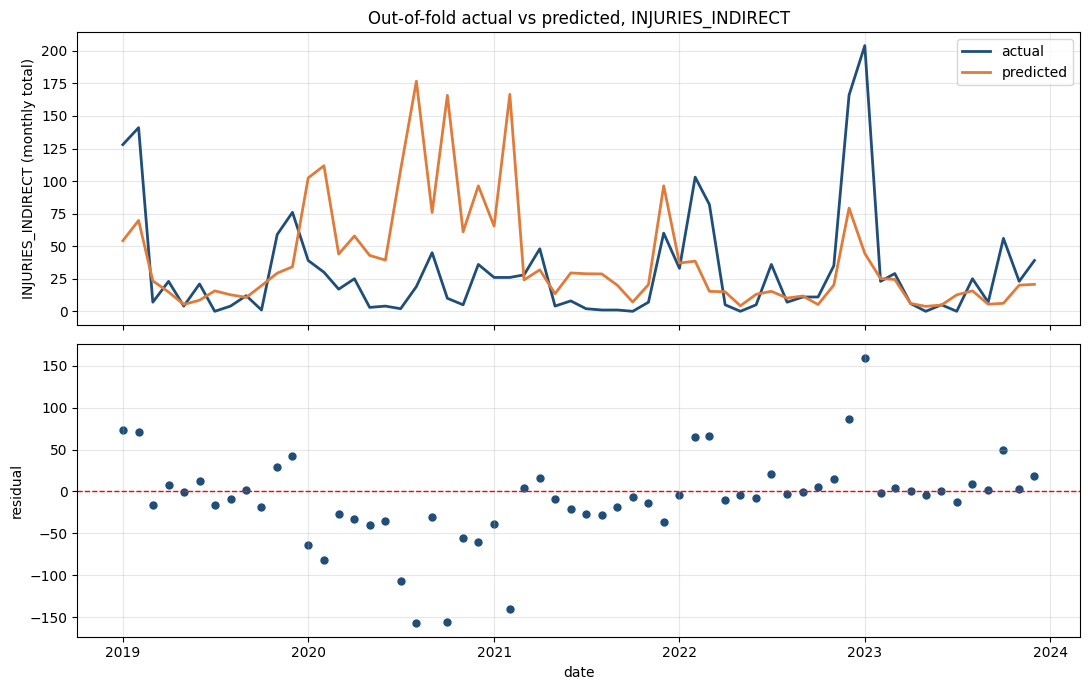

,n,events,D2,RMSE,MPD,ratio
year,,,,,,
2019,36353,88,0.4373,0.6075,0.1026,0.6266
2020,31055,76,-0.0758,0.2841,0.1064,4.6070
2021,36224,62,0.3951,0.2605,0.0494,2.5235
2022,42173,120,0.2362,0.4908,0.1198,0.5365
2023,39686,101,0.4107,0.4863,0.0859,0.4543


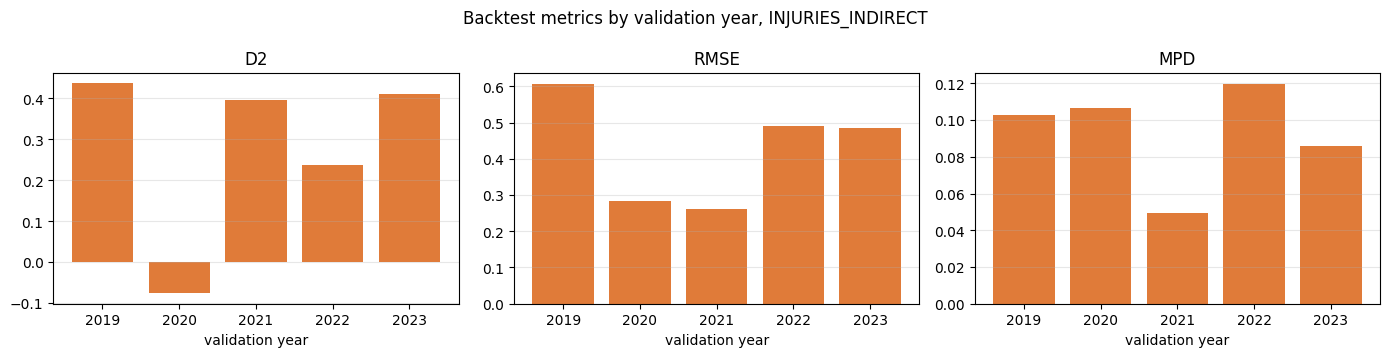

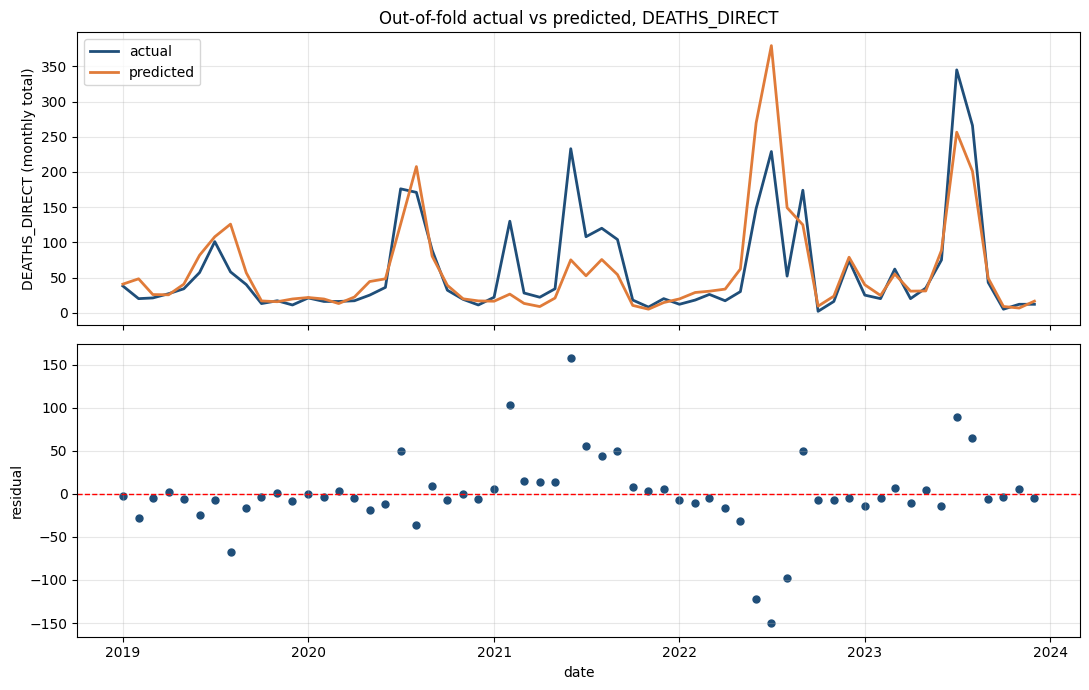

,n,events,D2,RMSE,MPD,ratio
year,,,,,,
2019,36353,333,0.6192,0.1284,0.0442,1.3836
2020,31055,300,0.5847,0.4183,0.0891,1.0469
2021,36224,428,0.5526,0.5854,0.1080,0.4400
2022,42173,353,0.5005,0.5243,0.1034,1.5155
2023,39686,409,0.6586,0.6921,0.0875,0.8782


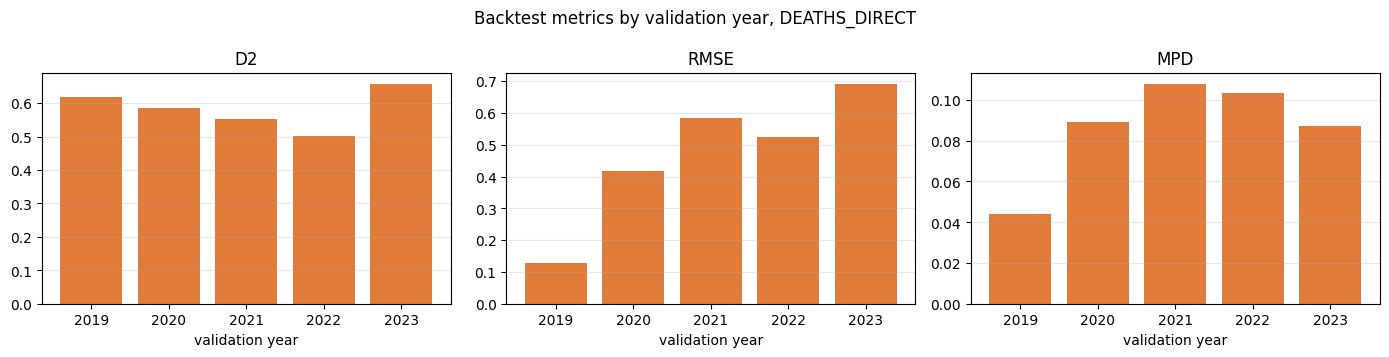

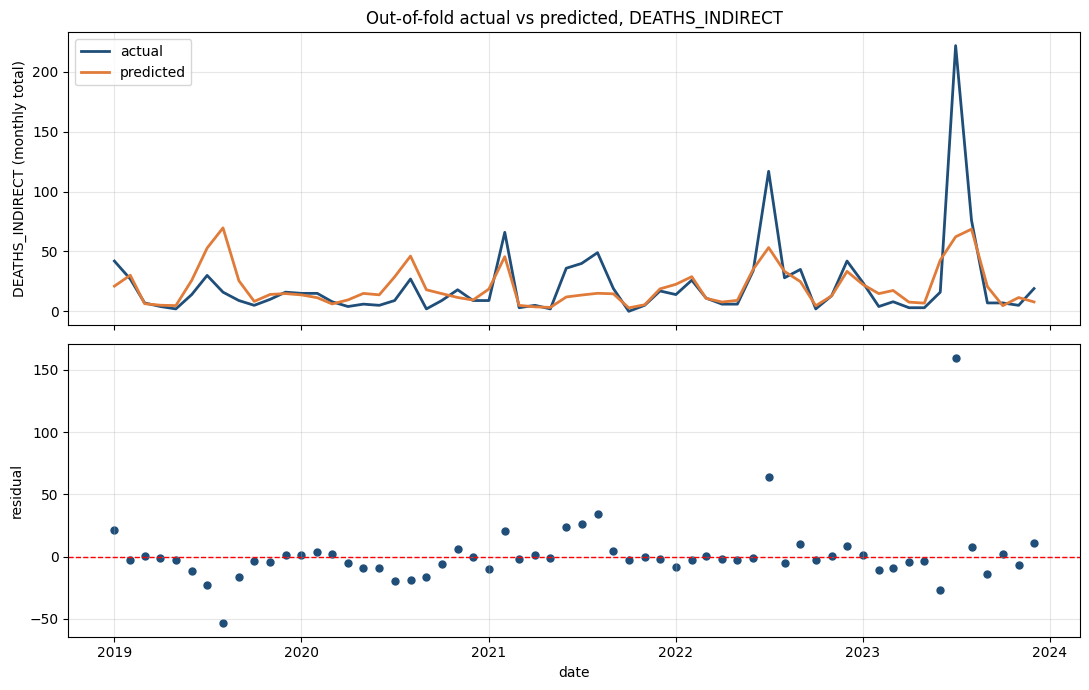

,n,events,D2,RMSE,MPD,ratio
year,,,,,,
2019,36353,152,0.4838,0.0791,0.0286,1.5308
2020,31055,87,0.2874,0.1068,0.0357,1.5606
2021,36224,156,0.5708,0.1316,0.0338,0.6317
2022,42173,188,0.6162,0.1431,0.0346,0.8286
2023,39686,136,0.5713,0.3779,0.0550,0.7296


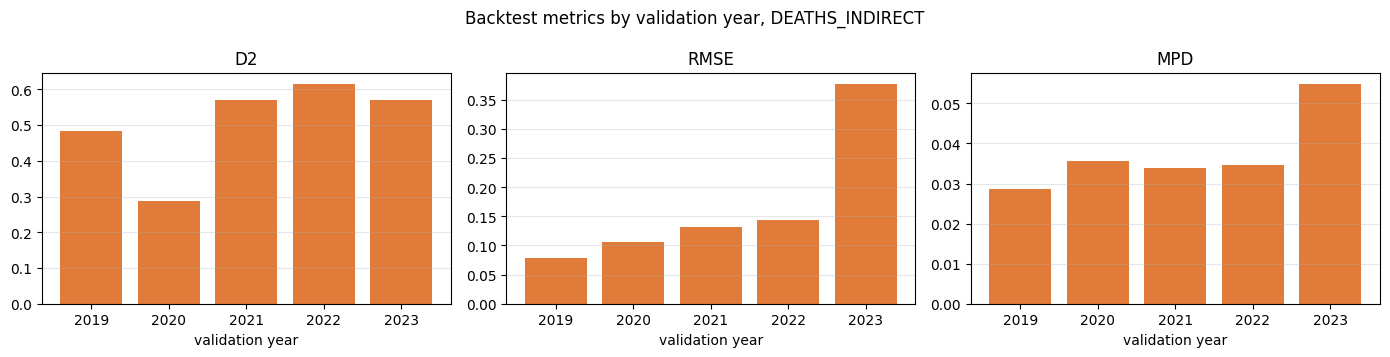

In [43]:
def backtest_report(frame, target):
    """Monthly out-of-fold fit, residuals over time, and metrics by validation year."""
    monthly = frame[["actual", "predicted"]].resample("MS").sum()
    monthly["residual"] = monthly["actual"] - monthly["predicted"]

    figure, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    axes[0].plot(monthly.index, monthly["actual"], color="#1f4e79", linewidth=2, label="actual")
    axes[0].plot(monthly.index, monthly["predicted"], color="#e07b39", linewidth=2,
                 label="predicted")
    axes[0].set_ylabel(f"{target} (monthly total)")
    axes[0].set_title(f"Out-of-fold actual vs predicted, {target}")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].scatter(monthly.index, monthly["residual"], color="#1f4e79", s=25)
    axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[1].set_ylabel("residual")
    axes[1].set_xlabel("date")
    axes[1].grid(alpha=0.3)
    figure.tight_layout()
    plt.show()

    by_year = pd.DataFrame([
        {"year": year, **compute_metrics(block["actual"], block["predicted"]),
         "ratio": block["predicted"].sum() / block["actual"].sum()}
        for year, block in frame.groupby("validation_year")
    ]).set_index("year")
    display(by_year.round(4))

    figure, axes = plt.subplots(1, 3, figsize=(14, 3.6))
    for axis, metric in zip(axes, ["D2", "RMSE", "MPD"]):
        axis.bar(by_year.index.astype(str), by_year[metric], color="#e07b39")
        axis.set_title(metric)
        axis.set_xlabel("validation year")
        axis.grid(alpha=0.3, axis="y")
    figure.suptitle(f"Backtest metrics by validation year, {target}")
    figure.tight_layout()
    plt.show()
    return by_year


backtest_by_year = {target: backtest_report(frame, target) for target, frame in oof.items()}

### Interpretability

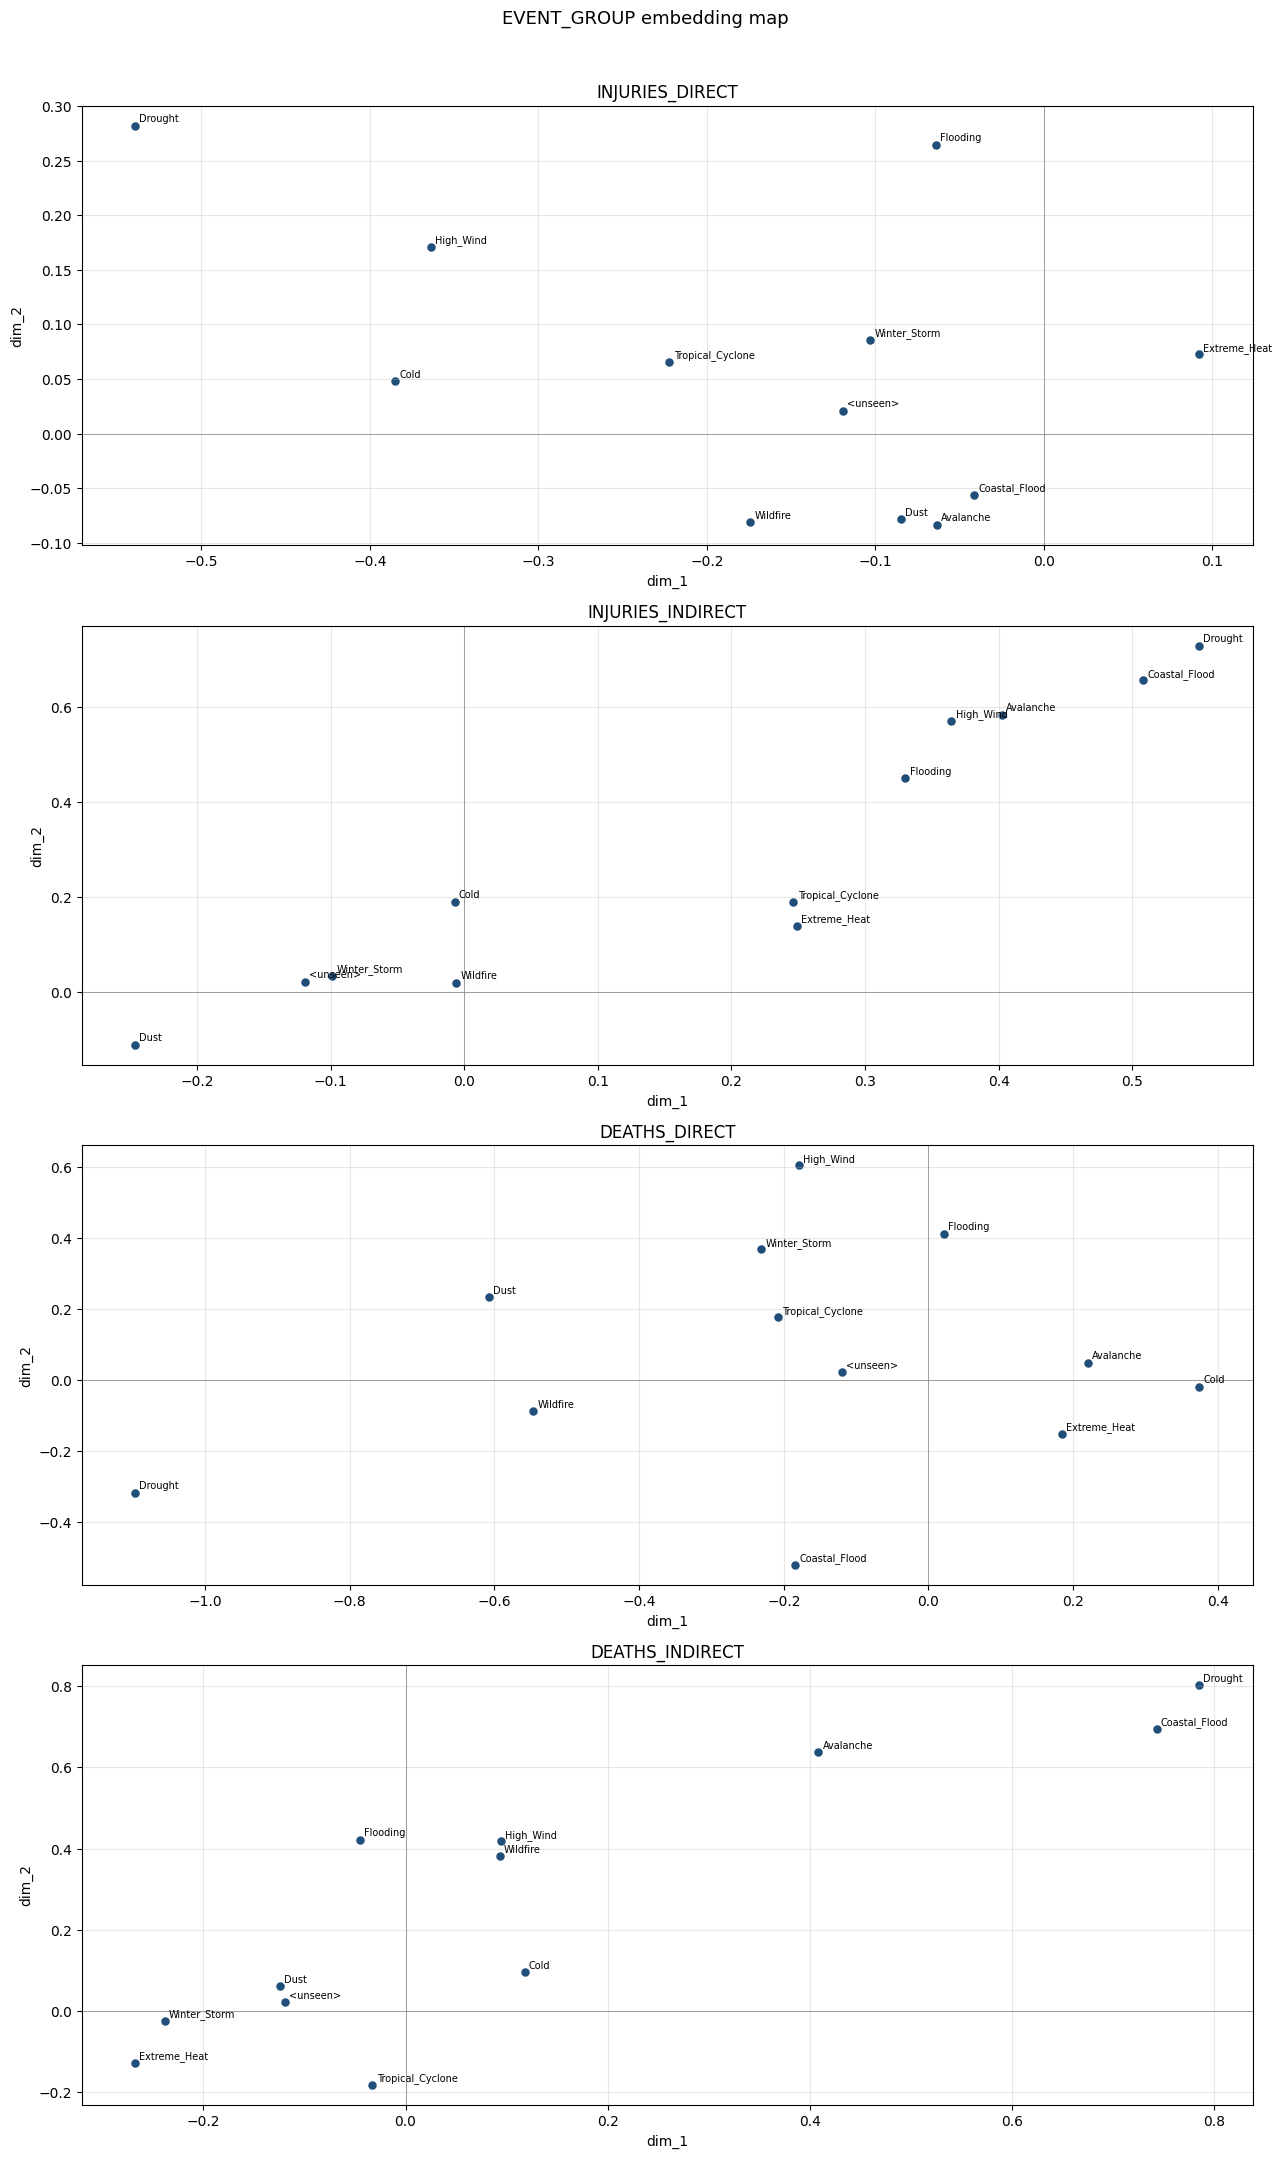

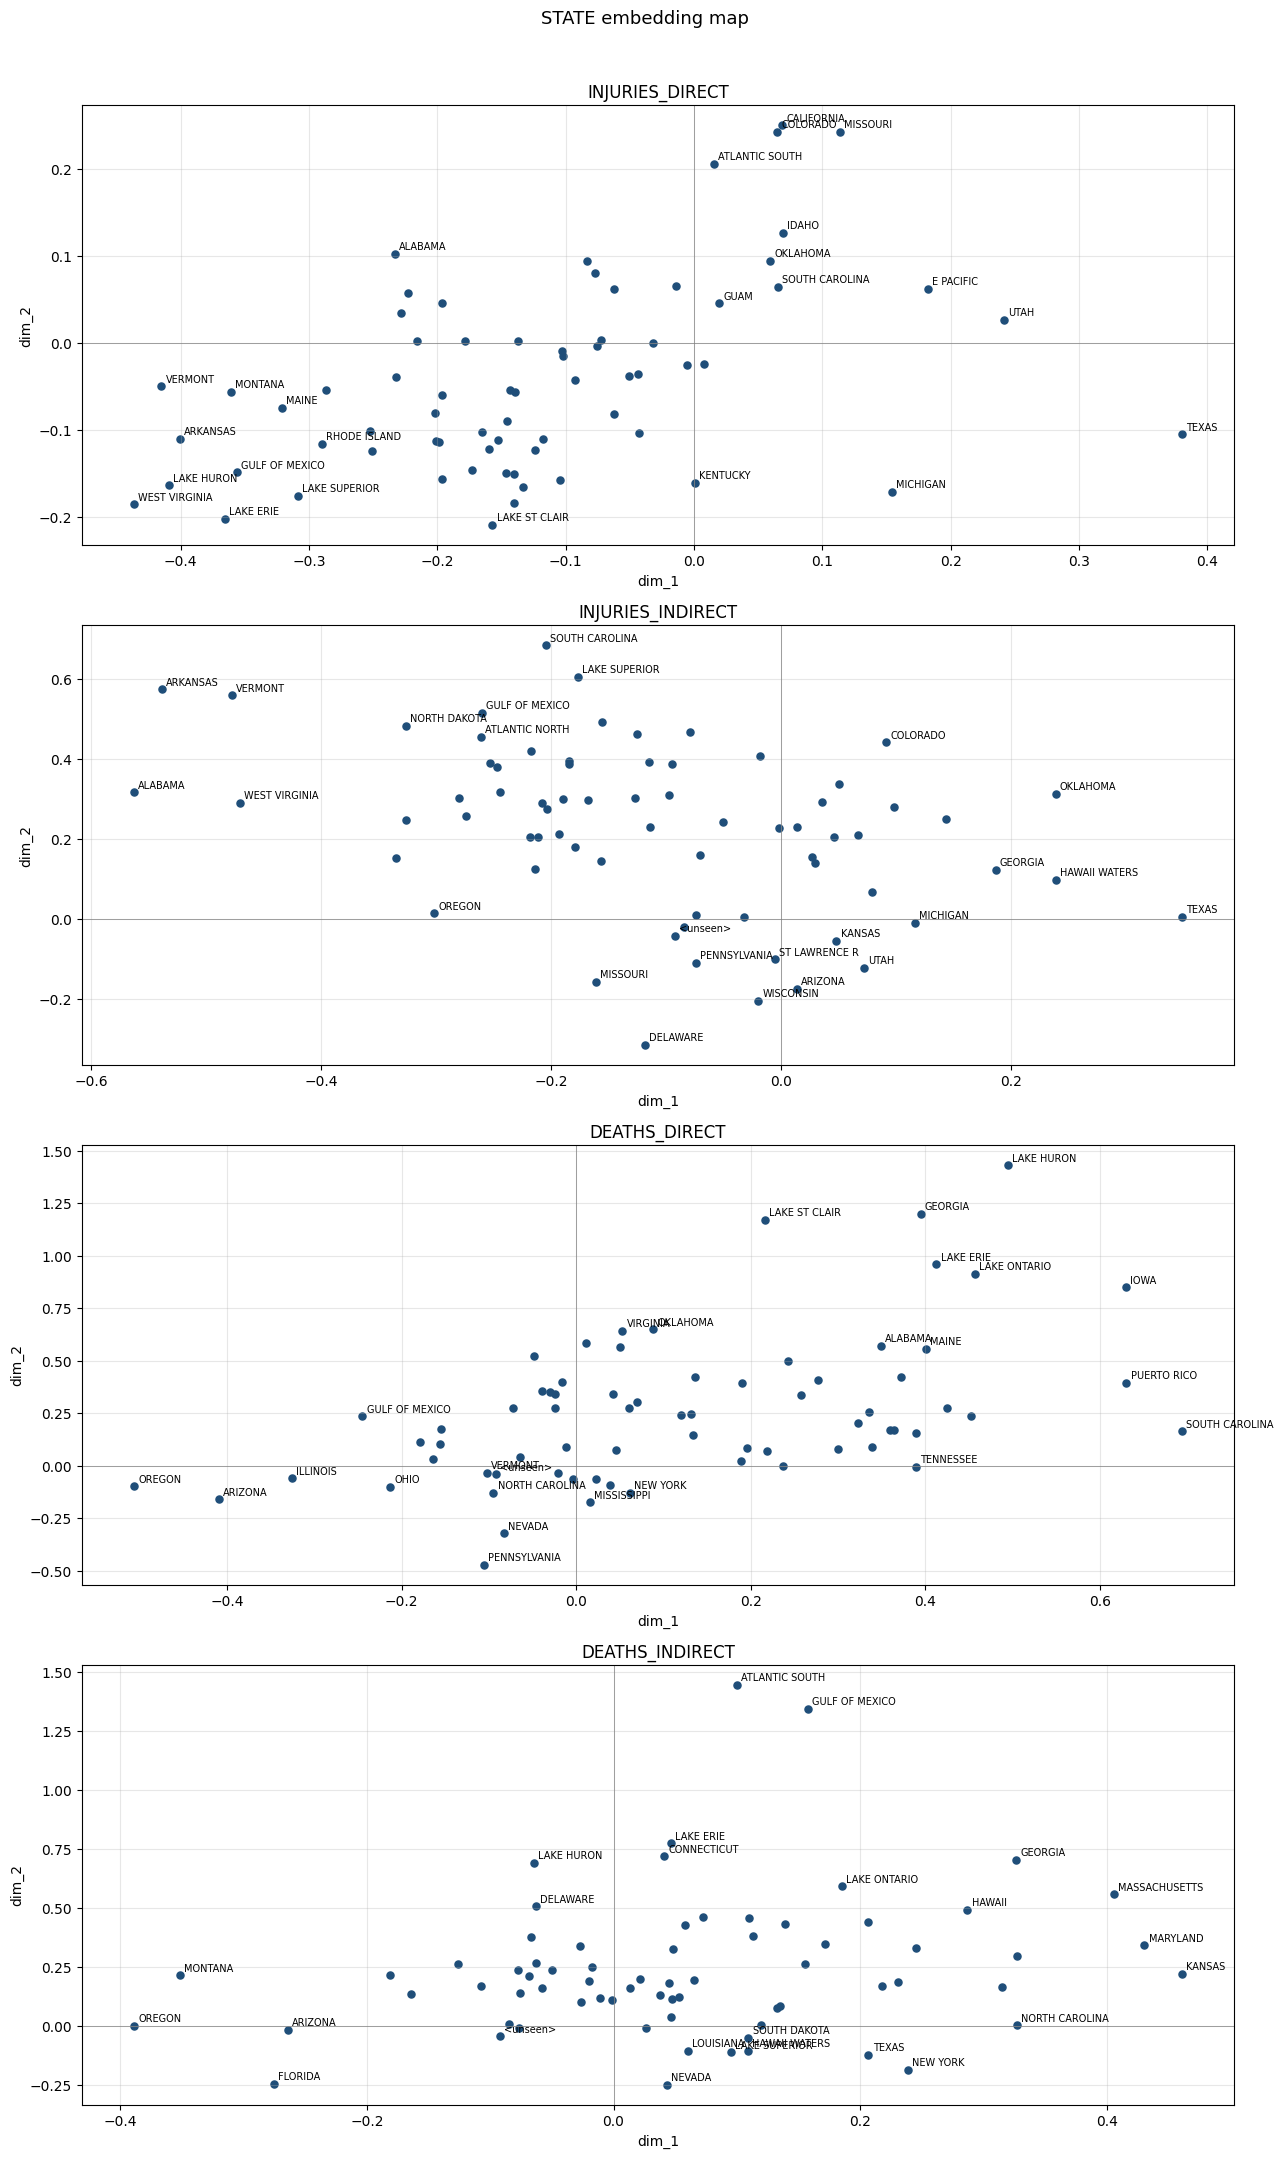

In [44]:
def embedding_map(result, column):
    """The two-dimensional lookup table itself, one row per level."""
    table = result["params"]["categorical_tables"][column].weight.detach().cpu().numpy()
    levels = ["<unseen>"] + list(ENCODERS["vocabularies"][column])
    return pd.DataFrame(table, index=levels, columns=["dim_1", "dim_2"])


def plot_embedding_column(column, targets=PREDICTION_TARGETS, max_labels=25):
    """One 2D embedding map per target model, stacked so every panel gets the full figure width.

    Only the `max_labels` points furthest from the centre of the map are annotated: with seventy
    states every label drawn is a label unreadable.
    """
    figure, axes = plt.subplots(len(targets), 1, figsize=(13.0, 5.4 * len(targets)), squeeze=False)
    for axis, target in zip(axes.ravel(), targets):
        frame = embedding_map(results[target], column)
        axis.scatter(frame["dim_1"], frame["dim_2"], s=26, color="#1f4e79")

        distance = (frame - frame.mean()).pow(2).sum(axis=1)
        for label, row in frame.loc[distance.nlargest(max_labels).index].iterrows():
            axis.annotate(label, (row["dim_1"], row["dim_2"]), fontsize=7,
                          xytext=(3, 3), textcoords="offset points")

        axis.axhline(0, color="grey", linewidth=0.5)
        axis.axvline(0, color="grey", linewidth=0.5)
        axis.grid(alpha=0.3)
        axis.set(xlabel="dim_1", ylabel="dim_2", title=target)

    figure.suptitle(f"{column} embedding map", y=0.997, fontsize=13)
    figure.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()


for column in ("EVENT_GROUP", "STATE"):
    plot_embedding_column(column)

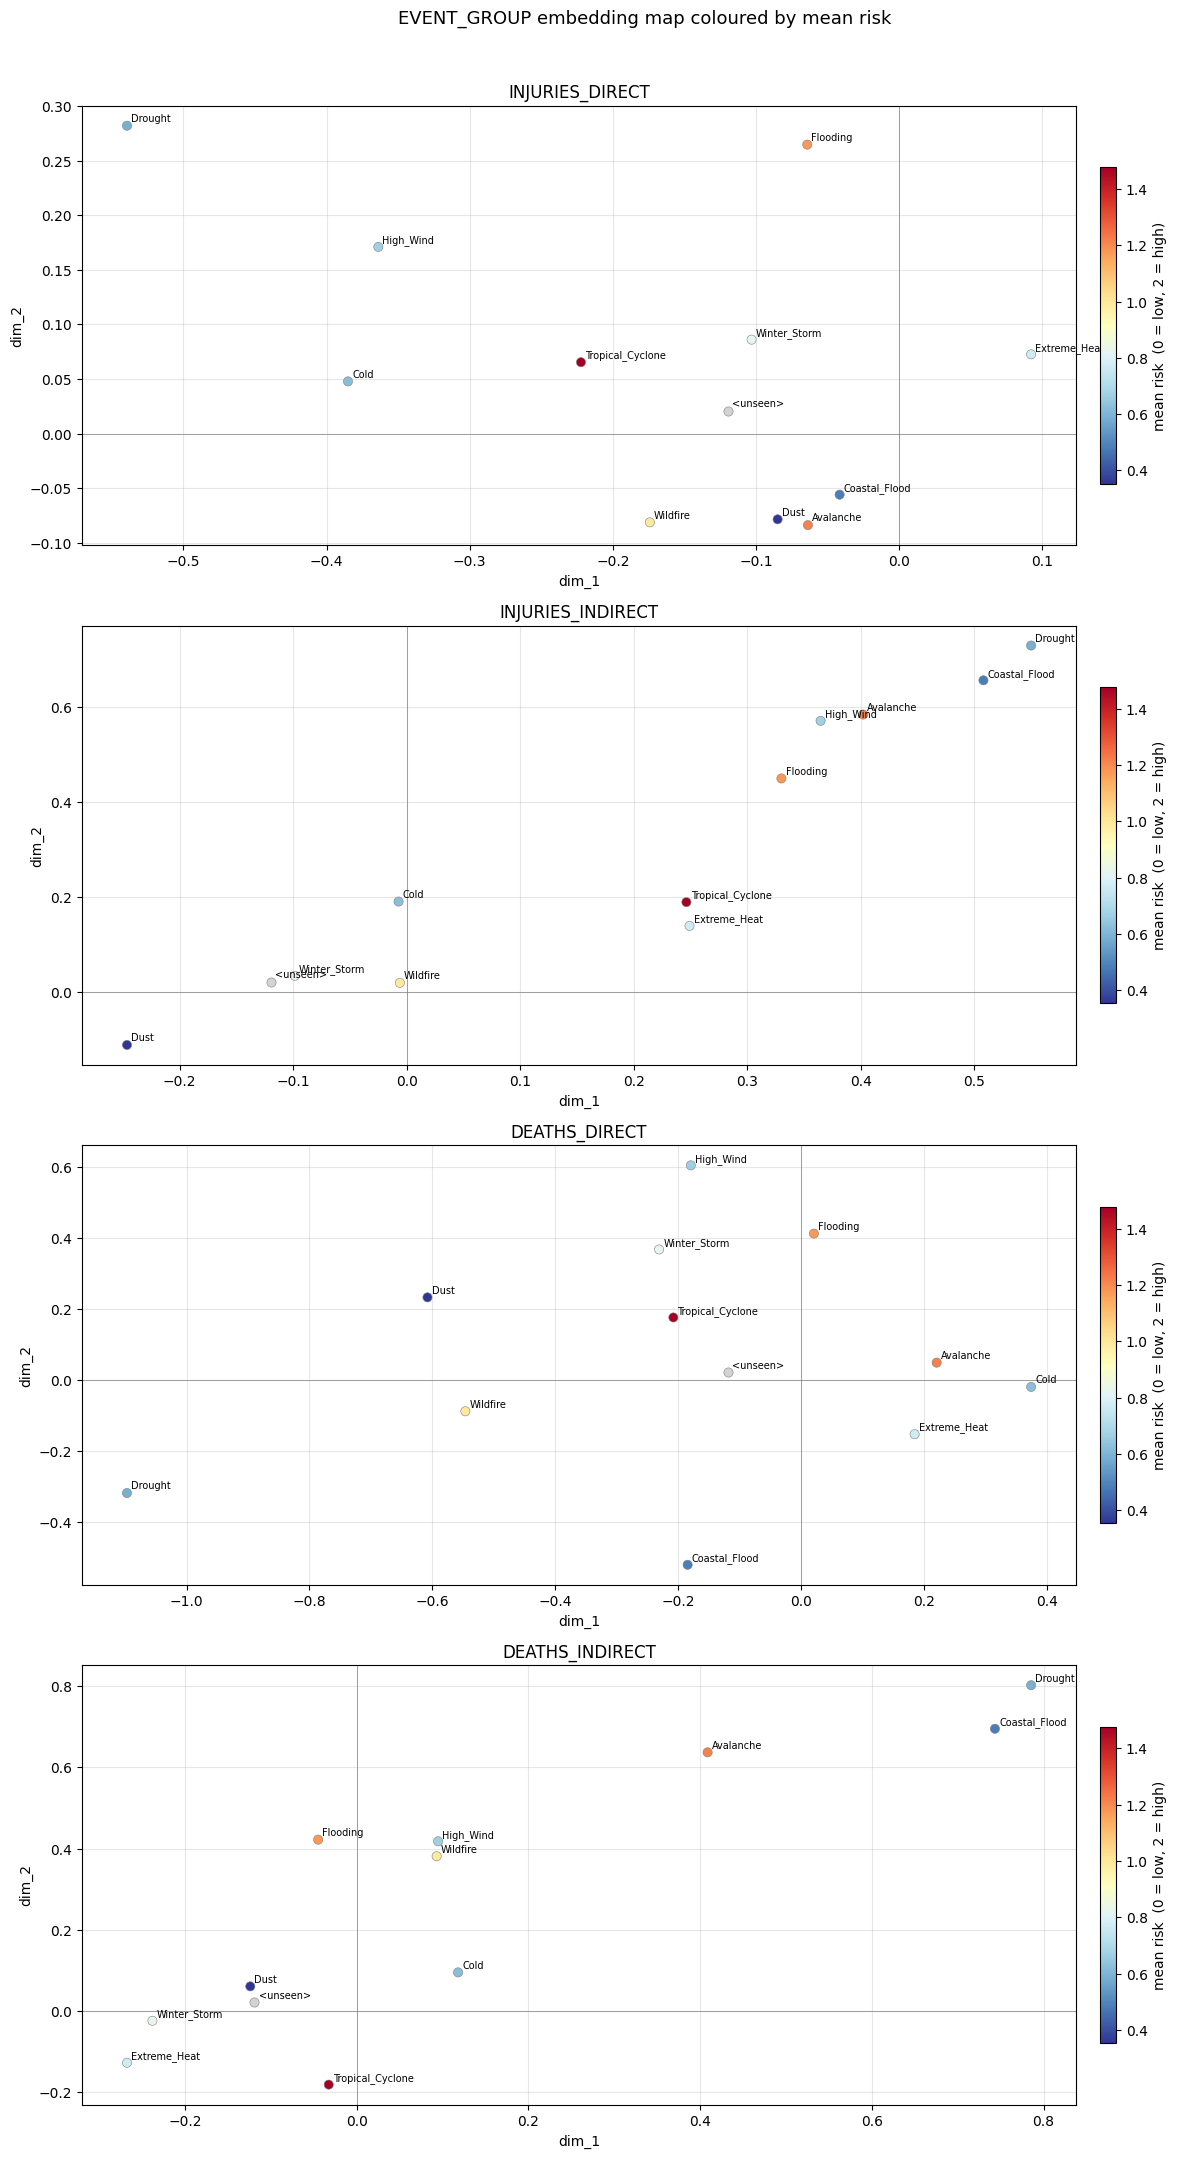

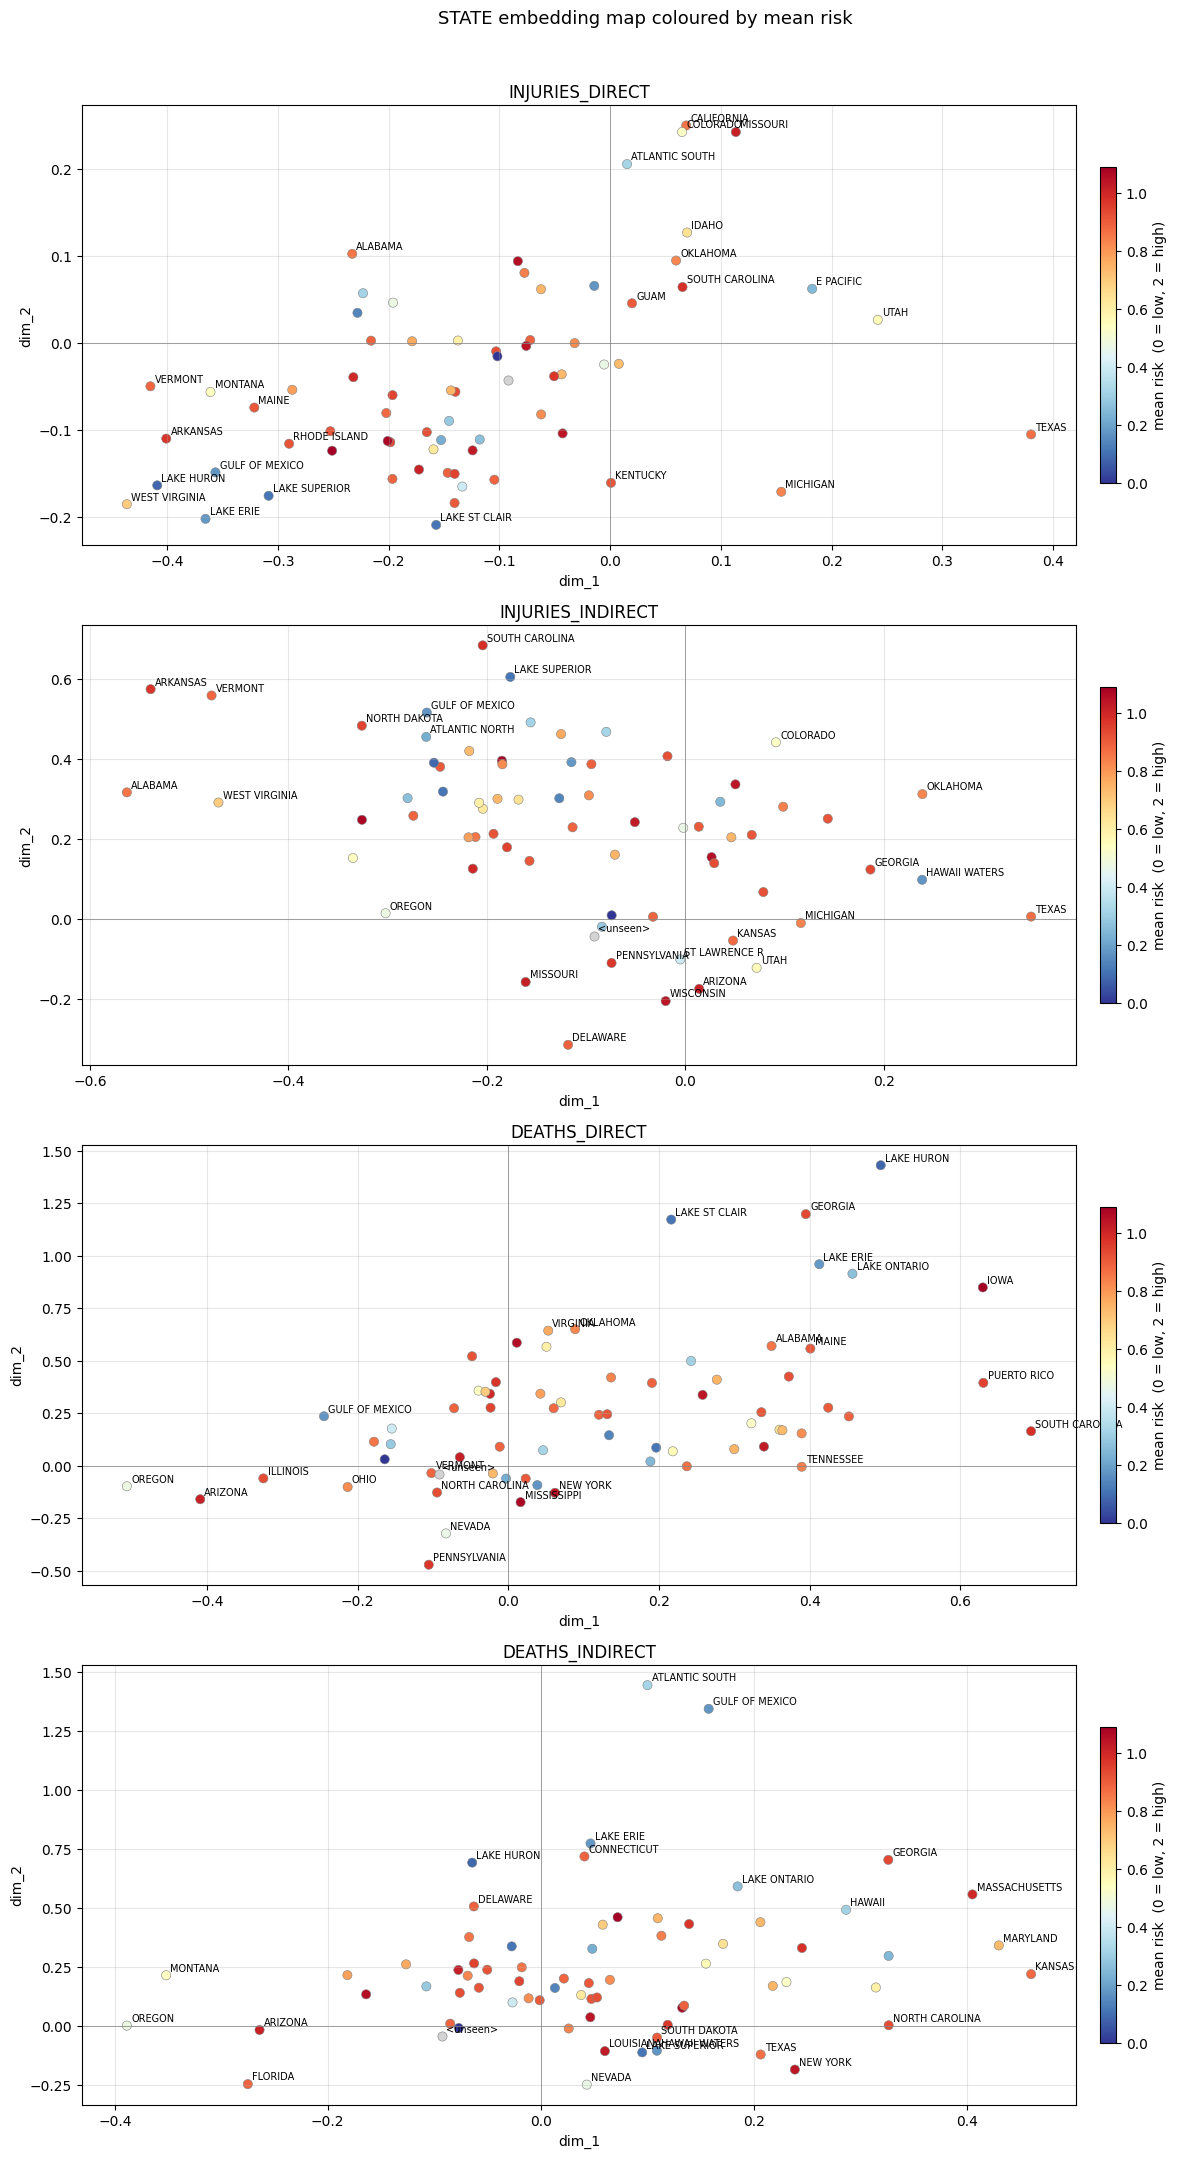

In [50]:
def embedding_map(result, column):
    """The two-dimensional lookup table itself, one row per level."""
    table = result["params"]["categorical_tables"][column].weight.detach().cpu().numpy()
    levels = ["<unseen>"] + list(ENCODERS["vocabularies"][column])
    return pd.DataFrame(table, index=levels, columns=["dim_1", "dim_2"])


def level_risk_score(frame, column):
    """Mean ordinal risk per level of `column`: low=0, medium=1, high=2."""
    scale = {name: position for position, name in enumerate(ORDINAL_LEVELS["risk"])}
    scored = frame["risk"].map(scale).astype("float64")
    return scored.groupby(frame[column], observed=True).mean().rename("risk_score")


def plot_embedding_column(column, colour_by=None, three_d=False,
                          targets=PREDICTION_TARGETS, source=None, max_labels=25):
    """One panel per target model, stacked so that every panel gets the full figure width.
    """
    source = train_events if source is None else source
    depth = {"depthshade": False} if three_d else {}


    panel = (10.0, 6.2) if three_d else (13.0, 5.4)
    figure = plt.figure(figsize=(panel[0], panel[1] * len(targets)))
    for position, target in enumerate(targets, start=1):
        frame = embedding_map(results[target], column)
        if colour_by is not None:
            frame["colour"] = frame.index.map(colour_by).to_numpy(dtype="float64")

        axis = figure.add_subplot(len(targets), 1, position,
                                  projection="3d" if three_d else None)
        names = ["dim_1", "dim_2", "trend"] if three_d else ["dim_1", "dim_2"]
        coordinates = [frame[name] for name in names]

        if colour_by is None:
            axis.scatter(*coordinates, s=26, color="#1f4e79", **depth)
        else:
            known = frame["colour"].notna()
            drawn = axis.scatter(*[c[known] for c in coordinates], c=frame.loc[known, "colour"],
                                 cmap="RdYlBu_r", s=44, edgecolor="grey", linewidth=0.4, **depth)
            if not known.all():
                axis.scatter(*[c[~known] for c in coordinates], s=44, color="lightgrey",
                             edgecolor="grey", linewidth=0.4, **depth)
            figure.colorbar(drawn, ax=axis, shrink=0.72, pad=0.02,
                            label="mean risk  (0 = low, 2 = high)")

        labelled = frame
        if len(frame) > max_labels:
            centred = frame[["dim_1", "dim_2"]] - frame[["dim_1", "dim_2"]].mean()
            labelled = frame.loc[centred.pow(2).sum(axis=1).nlargest(max_labels).index]
        for label, row in labelled.iterrows():
            if three_d:
                axis.text(row["dim_1"], row["dim_2"], row["trend"], label, fontsize=6)
            else:
                axis.annotate(label, (row["dim_1"], row["dim_2"]), fontsize=7,
                              xytext=(3, 3), textcoords="offset points")

        axis.set_xlabel("dim_1")
        axis.set_ylabel("dim_2")
        axis.axhline(0, color="grey", linewidth=0.5)
        axis.axvline(0, color="grey", linewidth=0.5)
        axis.grid(alpha=0.3)
        axis.set_title(target)

    parts = [column, "embedding map"]
    if colour_by is not None:
        parts.append("coloured by mean risk")
    figure.suptitle(" ".join(parts), y=0.997, fontsize=13)
    figure.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()


EMBEDDING_COLUMNS = ("EVENT_GROUP", "STATE")
RISK_SCORE = {column: level_risk_score(train_events, column) for column in EMBEDDING_COLUMNS}

for column in EMBEDDING_COLUMNS:
    plot_embedding_column(column, colour_by=RISK_SCORE[column])
